In [2]:
import re

import torch
import matplotlib
from matplotlib.ticker import FuncFormatter, MaxNLocator
from matplotlib import pyplot as plt
from matplotlib.colors import SymLogNorm
import matplotlib.patches as mpatches
import numpy as np
import pysam
import pandas as pd
import logomaker
from functools import partial
from collections import defaultdict

from methylseqnet.predict import Predictor
from methylseqnet.readers import load_total_counts
from methylseqnet_repro.paths import model_checkpoints, genomes, methylation_atlas, atac_atlas, cage_atlas, annotations, haplotypes, fiberseq_tracks, rna_tracks, pacbio_5mC_tracks
from methylseqnet.annotations import fetch_tss_from_gtf, load_bed_intervals, load_annotated_bed_rows
from methylseqnet.transforms import UniformTransform, DinucShuffleSyntheticCpG, DinucShufflePreserveMethylation, InsertSyntheticCpG
from methylseqnet.tensor_ops import interpolate_methyl_with_mask
from methylseqnet.encoding import ONE_HOT_DNA_CHANNELS

In [3]:
# model_folder = model_checkpoints / "slurm31983102task0" / "checkpoints"
model_folder = model_checkpoints / "slurm32260895task0" / "checkpoints"
best_ckpt = max(
    model_folder.glob('best*.ckpt'),
    key=lambda p: p.stat().st_mtime
)
seq_only_model_folder = model_checkpoints / "slurm32260895task1" / "checkpoints"
seq_only_best_ckpt = max(
    seq_only_model_folder.glob('best*.ckpt'),
    key=lambda p: p.stat().st_mtime
)
conditioned_predictor = Predictor(best_ckpt,supplemental_outputs={"true_conditioning_state_rep","imputed_conditioning_state_rep","sequence","conditioning_state"})
unconditioned_predictor = Predictor(seq_only_best_ckpt,supplemental_outputs={"true_conditioning_state_rep","imputed_conditioning_state_rep","sequence","conditioning_state"})
io_mappings_df = conditioned_predictor.model.get_io_mappings_df()
cropper = conditioned_predictor.model.crop_sequence_match_output

seq_baseline = DinucShufflePreserveMethylation()
# seq_baseline = UniformTransform()
methyl_baseline = InsertSyntheticCpG(center_window_size=-1, center_cpg_frac=0.95)
baselines_per_sample = 1
motif_thresh = 12

offset_for_pancreas_logo = -2550
# imprint_chrom = "chr13" # decent option
# imprint_tss = 41132802
imprint_chrom = "chr2"
imprint_tss = 80304752


hg38 = genomes / "hg38.fa"
chr13_len = pysam.FastaFile(hg38).get_reference_length("chr13")
chrX_len = pysam.FastaFile(hg38).get_reference_length("chrX")
# der(13) junction: chr13:35,480,297 | chrX:24,535,860
bp13_der13 = 35_480_297   # end of chr13 segment A on der(13)
bpX_der13  = 24_535_860   # end of chrX segment C on der(13)
#
# der(X) junction: chrX:24,535,842 | chr13:35,480,299
bpX_derX   = 24_535_842   # start of chrX segment D on der(X)
bp13_derX  = 35_480_299   # start of chr13 segment B on der(X)

def convert_chrX_to_derX_fwd(pos):
    return (chr13_len - bp13_derX) + (pos - bpX_derX)
def convert_chr13_to_derX_rev(pos):
    return (chrX_len - bpX_derX) + (pos - bp13_derX)

gtf_annotation = annotations / "gencode.v49.basic.annotation.sorted.gtf.gz"
motifs_annotation = annotations / "hg38.archetype_motifs.v1.0.bed.gz"
cpg_islands = annotations / "hg38_cpgIsland.bed"
udn_hp1_fasta_file = haplotypes / "UDN318336.hg38.HP1.fa"
udn_hp2_fasta_file = haplotypes / "UDN318336.hg38.HP2.fa"
udn_hp1_fusion_fasta_file = haplotypes / "UDN318336.hg38.derXder13.fa"
udn_hp1_methylation_files = [
    pacbio_5mC_tracks / "UDN318336_retinal.aligned_bam_to_cpg_scores.hap1.bw"
]
udn_hp2_methylation_files = [
    pacbio_5mC_tracks / "UDN318336_retinal.aligned_bam_to_cpg_scores.hap2.bw"
]
udn_hp1_fusion_methylation_files = [
    pacbio_5mC_tracks / "UDN318336_retinal.hg38.derXder13.cpg_scores.hap1.bw"
]
udn_hp1_fiber_files = [
    # "/global/scratch/projects/vector_streetslab/oberon/datasets/vollger_mendelian/FIRE/UDN318336_trackHub/bw/hap1.percent.accessible.bw"
    # "/global/scratch/projects/vector_streetslab/oberon/datasets/vollger_mendelian/FIRE/
    fiberseq_tracks / "UDN318336_retinal_trackHub/bw/hap1.acc.bw"
]
udn_hp2_fiber_files = [
    # "/global/scratch/projects/vector_streetslab/oberon/datasets/vollger_mendelian/FIRE/UDN318336_trackHub/bw/hap2.percent.accessible.bw"
    # "/global/scratch/projects/vector_streetslab/oberon/datasets/vollger_mendelian/FIRE/UDN318336_trackHub/bw/hap2.acc.bw"
    fiberseq_tracks / "UDN318336_retinal_trackHub/bw/hap2.acc.bw"
]
udn_hp1_fusion_fiber_files = [
    fiberseq_tracks / "UDN318336_retinal_trackHub" / "bw" / "hap1.derXder13.acc.bw"
]

# when using the fusion labels, reference the normal genome-wide files for normalization since the fusion files only cover the der(13) and der(X) segments
udn_hp1_manual_counts_normalizations = np.mean( 
    [
        load_total_counts(udn_hp1_fiber_file)
        for udn_hp1_fiber_file in (
            udn_hp1_fiber_files if isinstance(udn_hp1_fiber_files,list)
            else [udn_hp1_fiber_files]
            )
    ]
) / 1e9

# Pancreas Acinar setup files
cell_types = [
    "Pancreas-Acinar",
    "Adipocyte",
    "Pancreas-Alpha",
    "Lung-Alveolar-Epithel", 
    "Blood-B-Mem",
    "Heart-Cardiomyocyte",
    "Liver-Hepatocytes",   
    "Colon-Left-Epithelial",
]
atac_tasks_dict = {}
atac_files_dict = {}
methylation_files_dict = {}
for cell_type in cell_types:
    atac_tasks_dict[cell_type] = io_mappings_df[
        (io_mappings_df["methylation_files"].str.contains(cell_type))
        & (io_mappings_df["data_type"] == "ATAC-seq")
    ]["absolute_channel"].to_list()
    atac_file_descriptions = io_mappings_df[
    (io_mappings_df["methylation_files"].str.contains(cell_type))
    & (io_mappings_df["data_type"] == "ATAC-seq")
    ]["label_files"].to_list()
    search_term = atac_file_descriptions[0].strip("'[]").split(", ")[0].replace(' ','%20').strip("'")
    atac_files_dict[cell_type] = [
        f for f in (atac_atlas / "bigwigs").glob(f"*{search_term}*.bw")
        if not f.name.startswith("Fetal")
    ]
    methylation_files_dict[cell_type] = list((methylation_atlas / "GSE186458_RAW").glob(f"*{cell_type}*hg38.bigwig"))

# GM12878 setup files
gm_hp1_fasta_file = haplotypes / "NA12878.hg38.hp1.fa"
gm_hp2_fasta_file = haplotypes / "NA12878.hg38.hp2.fa"
gm_fiber_tasks = io_mappings_df[
    (io_mappings_df["data_type"] == "Fiber-seq")
]["absolute_channel"].to_list()
gm_hp1_methylation_files = [
    pacbio_5mC_tracks / "GM12878_WGS-pb-5mC.hap1.bw"
]
gm_hp2_methylation_files = [
    pacbio_5mC_tracks / "GM12878_WGS-pb-5mC.hap2.bw"
]
gm_hp1_fiber_files = [
    fiberseq_tracks / "GM12878_trackHub/bw/hap1.acc.bw"
]
gm_hp2_fiber_files = [
    fiberseq_tracks / "GM12878_trackHub/bw/hap2.acc.bw"
]
gm_rna_tasks = io_mappings_df[
    (io_mappings_df["data_type"] == "RNA-seq")
]["absolute_channel"].to_list()
gm_hp1_rna_files = [
    rna_tracks / "GM12878.kinnex.HP2.no5exon.tss.counts.bed.gz"
]
gm_hp2_rna_files = [
    rna_tracks / "GM12878.kinnex.HP1.no5exon.tss.counts.bed.gz"
]

In [4]:
matplotlib.rcParams['hatch.linewidth'] = 0.5
def fillbetween_track(ax, x, y, color, description="", label="", alpha=1.0, linewidth=0.5, baseline=0, vmax=None, targets_fcn=None, **kwargs):
    ax.fill_between(x, y, baseline, alpha=alpha,
                    linewidth=linewidth, color=color, **kwargs)
    for spine in ["top", "right", "left", "bottom"]:
        ax.spines[spine].set_visible(False)
    ax.set_ylabel(label, rotation=0, ha='right', va='center', labelpad=10)
    ax.axhline(0, color='black', linestyle='-', linewidth=2)
    if targets_fcn is not None and targets_fcn is torch.log1p:
        # ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{np.expm1(v):.2g}"))
        # ymin, ymax = ax.get_ylim()
        # ax.set_yticks([0, ymax])
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{np.expm1(v):.3g}"))
        true_max = np.expm1(ax.get_ylim()[1])
        magnitude = 10 ** np.floor(np.log10(true_max))
        top_tick_true = np.floor(true_max / magnitude) * magnitude  # e.g. 100 for max=150
        ax.set_yticks([0, np.log1p(top_tick_true)])
    ax.tick_params(axis='y', which='both', right=True, left=True, labelright=True, labelleft=True)
    for tl in ax.get_yticklabels(which='both'):
        tl.set_color(kwargs.get('edgecolor', color))

def symlog_ticks(vmin, vmax, linthresh, tick_count):
    """Pick tick_count ticks at nice symmetric symlog values."""
    amax = abs(vmax)
    
    # Actual powers of 10 that are >= linthresh and < amax/10
    pos = [amax]
    exp = int(np.floor(np.log10(amax / 10)))  # at least one full order below
    while 10**exp >= linthresh:
        pos.append(10**exp)
        exp -= 1
    pos = sorted(pos)

    while 1 + 2 * len(pos) > tick_count:
        pos.pop(0)

    ticks = [-p for p in reversed(pos)] + [0] + pos
    return ticks

def make_colorbar_figure(label, description="", cmap='RdBu_r', vmin=-1, vmax=1,
                         linthresh=None, norm_type='symlog',
                         figsize=(6, 0.4), orientation='horizontal',
                         tick_count=5):
    """
    Create a separate figure containing only a horizontal colorbar.
    
    Parameters
    ----------
    label : str
        Title displayed above the colorbar.
    cmap : str
        Colormap name.
    vmin, vmax : float
        Color limits.
    linthresh : float or None
        For SymLogNorm; ignored if norm_type='linear'.
    norm_type : 'symlog' or 'linear'
        Which normalization to use.
    figsize : tuple
        Figure size in inches.
    orientation : str
        'horizontal' or 'vertical'.
    tick_count : int
        Approximate number of ticks.
    
    Returns
    -------
    fig : matplotlib.figure.Figure
    """
    from matplotlib.colors import SymLogNorm, Normalize
    from matplotlib.cm import ScalarMappable
    import matplotlib.pyplot as plt

    if norm_type == 'symlog':
        if linthresh is None:
            linthresh = vmax * 0.01
        norm = SymLogNorm(linthresh=linthresh, vmin=vmin, vmax=vmax)
    else:
        norm = Normalize(vmin=vmin, vmax=vmax)

    sm = ScalarMappable(cmap=plt.get_cmap(cmap), norm=norm)
    sm.set_array([])

    fig, ax = plt.subplots(figsize=figsize)
    for spine in ["top", "right", "left", "bottom"]:
        ax.spines[spine].set_visible(False)
    ax.axis('off')

    cbar = fig.colorbar(sm, ax=ax, orientation=orientation,
                        fraction=0.9, pad=0.01, aspect=5)
    cbar.ax.set_title(label, fontsize=9, pad=6)
    cbar.ax.tick_params(labelsize=7)
    cbar.outline.set_visible(False)

    if norm_type == 'symlog':
        ticks = symlog_ticks(vmin, vmax, linthresh, tick_count)
        cbar.set_ticks(ticks)
        cbar.set_ticklabels([f"{t:.2g}" for t in ticks])
        cbar.ax.minorticks_off()

    safe_label = re.sub(r'[\s/\\]', '_', label)
    fig.savefig(
        f"pdfs/{description.replace(' ','_')}_colorbar_{safe_label}.pdf",
        bbox_inches='tight', pad_inches=0.1)

def heatmap_track(ax, x, y, description="", label="", cmap='RdBu_r', linthresh=None, vmax=None, **kwargs):
    x_start, x_end = x[0], x[-1]
    y = np.asarray(y, dtype=np.float64)
    if vmax is None:
        vmax = np.abs(y).max()
    if linthresh is None:
        linthresh = vmax * 0.01
    norm = SymLogNorm(linthresh=linthresh, vmin=-vmax, vmax=vmax)
    ax.imshow(y[np.newaxis, :], aspect='auto', cmap=cmap,
              extent=[x_start, x_end, 0, 1], interpolation='bilinear',
              norm=norm, **kwargs)
    ax.set_yticks([])
    for spine in ["top", "right", "left", "bottom"]:
        ax.spines[spine].set_visible(False)
    ax.set_ylabel(label, rotation=0, ha='right', va='center', labelpad=40, y=-0.25)
    ax.yaxis.set_label_position('left')
    fig_heatmap_cbar = make_colorbar_figure(
        label, description=description, cmap=cmap, vmin=-vmax, vmax=vmax, linthresh=linthresh, norm_type='symlog',
    )

def add_gene_annotations(ax, transcripts, y_center=-0.5, row_height=0.3, 
                         fontsize=7, color='#2c3e50', arrow_lw=1.5,
                         block_width_frac=0.008, xlim=None):
    """
    Add gene annotations with directional arrows and labels below a genome track.
    
    Genes that extend beyond the visible window are still drawn, with their
    arrows clamped to the xlim boundaries and endpoint blocks omitted for
    any end that falls outside the view.
    
    Parameters
    ----------
    ax : matplotlib Axes
        The axes to draw on (typically shares x-axis with your profile plot).
    transcripts : list of dict
        Each dict has 'tss', 'threeprime', and 'gene_name'.
    y_center : float
        Vertical center for the first row of genes.
    row_height : float
        Vertical spacing between stacked genes (if overlapping).
    fontsize : int
        Font size for gene labels.
    color : str
        Base color for arrows/blocks.
    arrow_lw : float
        Line width for the transcript arrow body.
    block_width_frac : float
        Width of TSS/3' blocks as a fraction of the x-axis range.
    xlim : tuple or None
        (xmin, xmax) to use for scaling. If None, pulled from ax.get_xlim().
    """
    if xlim is None:
        xlim = ax.get_xlim()
    if xlim is None:
        xlim = ax.get_xlim()
    xmin, xmax = xlim
    flipped = xmin > xmax
    if flipped:
        xmin, xmax = xmax, xmin
    span = xmax - xmin
    block_w = span * block_width_frac

    # Filter to genes that overlap the visible window at all
    visible_tx = []
    for tx in transcripts:
        left = min(tx['tss'], tx['threeprime'])
        right = max(tx['tss'], tx['threeprime'])
        if right >= xmin and left <= xmax:
            visible_tx.append(tx)

    # Sort by start coordinate for overlap detection
    sorted_tx = sorted(visible_tx, key=lambda t: min(t['tss'], t['threeprime']))

    # Simple greedy row packing to avoid label collisions
    row_ends = []
    row_assignments = []
    for tx in sorted_tx:
        left = max(min(tx['tss'], tx['threeprime']), xmin)
        right = min(max(tx['tss'], tx['threeprime']), xmax)
        placed = False
        for i, rend in enumerate(row_ends):
            if left > rend + span * 0.02:
                row_ends[i] = right
                row_assignments.append(i)
                placed = True
                break
        if not placed:
            row_assignments.append(len(row_ends))
            row_ends.append(right)

    for tx, row in zip(sorted_tx, row_assignments):
        tss = tx['tss']
        tpe = tx['threeprime']
        name = tx['gene_name']
        y = y_center - row * row_height
        forward = tpe > tss

        # Determine which ends are within the visible window
        tss_visible = xmin <= tss <= xmax
        tpe_visible = xmin <= tpe <= xmax

        # Clamp arrow endpoints to visible range
        tss_clamped = max(xmin, min(tss, xmax))
        tpe_clamped = max(xmin, min(tpe, xmax))

        # Draw the arrow body (TSS -> 3')
        # Only use arrowhead if the 3' end is actually visible
        style = '->' if tpe_visible else '-'
        ax.annotate(
            '', xy=(tpe_clamped, y), xytext=(tss_clamped, y),
            arrowprops=dict(
                arrowstyle=style, lw=arrow_lw, color=color,
                mutation_scale=10,
            ),
        )

        # Block at TSS (taller, filled) — only if TSS is in view
        if tss_visible:
            tss_rect = mpatches.FancyBboxPatch(
                (tss - block_w / 2, y - row_height * 0.4),
                block_w, row_height * 0.8,
                boxstyle="round,pad=0.0",
                facecolor=color, edgecolor='none', zorder=3,
            )
            ax.add_patch(tss_rect)

        # Block at 3' end (smaller, open) — only if 3' is in view
        if tpe_visible:
            tpe_rect = mpatches.FancyBboxPatch(
                (tpe - block_w / 2, y - row_height * 0.3),
                block_w, row_height * 0.6,
                boxstyle="round,pad=0.0",
                facecolor='white', edgecolor=color, linewidth=1, zorder=3,
            )
            ax.add_patch(tpe_rect)

        # Gene name label at the visible midpoint
        vis_left = max(min(tss, tpe), xmin)
        vis_right = min(max(tss, tpe), xmax)
        mid = (vis_left + vis_right) / 2
        ax.text(mid, y + row_height * 0.45, name,
                fontsize=fontsize, fontstyle='italic', color=color,
                ha='center', va='bottom', clip_on=True)

    # Clean up the annotation axes
    ax.set_xlim(xlim)
    ymin = y_center - max(len(row_ends), 1) * row_height
    ax.set_ylim(ymin - row_height * 0.5, y_center + row_height)
    ax.axis('off')

def add_cpg_annotations(ax, cpg_islands, description="", y_center=0, row_height=0.3,
                        cmap_name='Greens', xlim=None, alpha=0.8,
                        edge_color='#1a6b3a', add_colorbar=True):
    from matplotlib.patches import Rectangle
    from matplotlib.cm import ScalarMappable
    from matplotlib.colors import Normalize
    import matplotlib.pyplot as plt

    if xlim is not None:
        xmin, xmax = xlim
        cpg_islands = [r for r in cpg_islands
                       if int(r[2]) > xmin and int(r[1]) < xmax]

    if not cpg_islands:
        ax.axis('off')
        return

    # CpG density: count per kb
    densities = [int(r[5]) / (int(r[2]) - int(r[1])) * 1000 for r in cpg_islands]
    norm = Normalize(vmin=0, vmax=150)
    cmap = plt.get_cmap(cmap_name)

    y_bot = y_center - row_height / 2

    for row, density in zip(cpg_islands, densities):
        start = int(row[1])
        end = int(row[2])

        rect = Rectangle((start, y_bot), end - start, row_height,
                          facecolor=cmap(norm(density)), edgecolor=edge_color,
                          alpha=alpha, linewidth=0.8, zorder=3)
        ax.add_patch(rect)

    ax.set_ylim(y_center - row_height, y_center + row_height)
    ax.axis('off')

    fig_cpg_cbar = make_colorbar_figure(
        label='CpG island density\n(count/kb)',
        description=description,
        cmap=cmap_name, vmin=0, vmax=150,
        norm_type='linear',
    )

def clean_motif_name(motif_id):
    """Extract readable TF name from motif_id like 'SP1_MOUSE.H11MO.0.A' or 'USF1_MA0093.2'"""
    name = motif_id.split('_')[0]
    # Some HOCOMOCO IDs use abbreviated names, expand common ones
    remap = {
        'TYY1': 'YY1', 'TF65': 'RELA', 'ZBT17': 'MIZ1', 'ZBT7A': 'LRF',
        'COE1': 'EBF1', 'SUH': 'RBPJ', 'ERR1': 'ESRRA', 'PRD16': 'PRDM16',
        'AP2A': 'TFAP2A', 'AP2B': 'TFAP2B', 'AP2C': 'TFAP2C',
        'SRBP1': 'SREBF1', 'SRBP2': 'SREBF2',
        'CTCFL': 'CTCF',
        'ELF2':'ETS family','FLI1':'ETS family','ELF1':'ETS family','ELF4':'ETS family',
        'TFAP2C':'TFAP2 family',
        'TBX20': 'TBX', 'TBX3': 'TBX', 'TBX5': 'TBX', 'TBX21': 'TBX',
    }
    return remap.get(name, name)

def motif_track(ax, motifs_df, clean_name_fn=clean_motif_name, palette=None):
    """Plot motif annotations with automatic lane stacking for overlaps."""
    if palette is None:
        palette = plt.cm.Set2.colors
    
    colors_map = {}
    y_positions = []
    
    for _, row in motifs_df.iterrows():
        fam = row['family']
        if fam not in colors_map:
            colors_map[fam] = palette[len(colors_map) % len(palette)]
        
        y = 0
        for prev_row, prev_y in y_positions:
            if prev_y == y and row['start'] < prev_row['end']:
                y += 1
        y_positions.append((row, y))
        
        label = clean_name_fn(row['motif_id'])
        ax.barh(y, row['end'] - row['start'], left=row['start'],
                height=0.6, color=colors_map[fam], edgecolor='black', linewidth=0.5, zorder=2)
        ax.text((row['start'] + row['end']) / 2, y - 0.5, label,
                ha='center', va='top', fontsize=6, rotation=0)
    
    max_y = max((y for _, y in y_positions), default=0)
    ax.set_ylim(-1.5, max_y + 1)
    ax.set_yticks([])
    ax.set_ylabel('TF motif\nscan', rotation=0, ha='right', va='center', labelpad=40)
    for spine in ax.spines.values():
        spine.set_visible(False)
def select_motifs(motif_df, attribution_signal, seq_start, 
                  score_thresh=10.0, attr_quantile=0.90, overlap_frac=0.5):
    """
    motif_df: DataFrame with columns [chrom, start, end, family, score, strand, motif_id, cluster]
    attribution_signal: 1D array of per-base attribution magnitudes (e.g. abs sum over ACGT)
    seq_start: genomic coordinate of attribution_signal[0]
    """
    # 0. drop uninformative hits
    blocklist_motif_id = re.compile(r'^ZN\d+[A-Z]?_')  # any ZN### entry
    blocklist_families = {'GC-tract', 'GCM'}
    mask = (
        ~motif_df['motif_id'].str.match(blocklist_motif_id)
        & ~motif_df['family'].isin(blocklist_families)
    )
    df = motif_df[mask].copy()

    # 1. score filter
    df = df[df['score'] >= score_thresh]
    
    # 2. collapse overlapping hits within same family
    # sort by family then score descending, greedily keep non-overlapping
    df = df.sort_values(['family', 'score'], ascending=[True, False])
    kept = []
    for family, group in df.groupby('family'):
        intervals = []
        for _, row in group.iterrows():
            overlaps = any(
                row['start'] < e and row['end'] > s 
                for s, e in intervals
            )
            if not overlaps:
                kept.append(row)
                intervals.append((row['start'], row['end']))
    df = pd.DataFrame(kept)
    
    if df.empty:
        return df
    
    # 3. filter by attribution overlap
    attr_thresh = np.quantile(attribution_signal[attribution_signal > 0], attr_quantile)
    high_attr = np.abs(attribution_signal) >= attr_thresh
    
    def has_attribution_support(row):
        s = int(row['start']) - seq_start
        e = int(row['end']) - seq_start
        s = max(s, 0)
        e = min(e, len(high_attr))
        if e <= s:
            return False
        motif_len = e - s
        n_high = high_attr[s:e].sum()
        return (n_high / motif_len) >= overlap_frac
    
    df = df[df.apply(has_attribution_support, axis=1)]
    
    return df.sort_values('start').reset_index(drop=True)
def collapse_overlapping_across_families(df, overlap_frac=0.5):
    """After per-family collapse, merge overlapping hits across families, keeping highest score."""
    if df.empty:
        return df
    df = df.sort_values('score', ascending=False).reset_index(drop=True)
    keep = []
    for _, row in df.iterrows():
        overlaps_kept = False
        for kept_row in keep:
            overlap_start = max(row['start'], kept_row['start'])
            overlap_end = min(row['end'], kept_row['end'])
            if overlap_end > overlap_start:
                overlap_len = overlap_end - overlap_start
                min_motif_len = min(row['end'] - row['start'], kept_row['end'] - kept_row['start'])
                if overlap_len / min_motif_len >= overlap_frac:
                    overlaps_kept = True
                    break
        if not overlaps_kept:
            keep.append(row)
    return pd.DataFrame(keep).sort_values('start').reset_index(drop=True)

In [4]:
# make_colorbar_figure(
#     label="Δ Sequence attributions",
#     description="",
#     cmap='RdBu_r',
#     vmin=-2,
#     vmax=2,
#     linthresh=None,
#     norm_type='symlog',
#     figsize=(2, 1),
#     orientation='horizontal',
#     tick_count=5,
# )
# make_colorbar_figure(
#     label="Δ Methylation attributions",
#     description="",
#     cmap='PuOr_r',
#     vmin=-2,
#     vmax=2,
#     linthresh=None,
#     norm_type='symlog',
#     figsize=(2, 1),
#     orientation='horizontal',
#     tick_count=5,
# )
# make_colorbar_figure(
#     label="Sequence attributions",
#     description="",
#     cmap='RdBu_r',
#     vmin=-5,
#     vmax=5,
#     linthresh=None,
#     norm_type='symlog',
#     figsize=(2, 1),
#     orientation='horizontal',
#     tick_count=5,
# )
# make_colorbar_figure(
#     label="Methylation attributions",
#     description="",
#     cmap='PuOr_r',
#     vmin=-5,
#     vmax=5,
#     linthresh=None,
#     norm_type='symlog',
#     figsize=(2, 1),
#     orientation='horizontal',
#     tick_count=5,
# )
# make_colorbar_figure(
#     label="CpG island density\n(count/kb)",
#     description="",
#     cmap='Greens',
#     vmin=0,
#     vmax=150,
#     linthresh=None,
#     norm_type='linear',
#     figsize=(2, 1),
#     orientation='horizontal',
#     tick_count=5,
# )


In [ ]:

offset_for_pancreas_logo = -2550
# imprint_chrom = "chr13" # decent option
# imprint_tss = 41132802
imprint_chrom = "chr2"
imprint_tss = 80304752
for predict_dict in [
    {
        "description":"Improved locus CEL in Pancreas Acinar cells",
        "sequence_path":hg38,
        "methylation_paths":methylation_files_dict["Pancreas-Acinar"],
        "target_paths":atac_files_dict["Pancreas-Acinar"],
        "tasks":atac_tasks_dict["Pancreas-Acinar"],
        "chromosome":"chr9",
        "start":133059832-524288//2 - 10_000,
        "end":133059832+524288//2 - 10_000,
        "logo_starts":[133_059_832 - 100 + offset_for_pancreas_logo, 133_061_981-100, 133_030_997-400, 133_054_350],
        "logo_ends":[133_059_832 + 100 + offset_for_pancreas_logo, 133_061_981+100, 133_030_997-200, 133_054_550],
        "logo_titles":["GH09J133054 enhancer, internal peak attributions", "CEL promoter attributions", "GTF3C5 promoter attributions", "GH09J133054 enhancer, near 5' end attributions"],
        "targets_fcn":torch.log1p,
        "plot_range":40000,
        "ylim_match_sets":[(0,1,3),(5, 7),],
        "target_assay":"ATAC-seq",
        "prediction_assay":"ATAC-seq",
        "methylation_assay":"WGBS",
        "imputed_methylation_assay":"WGBS",
    },
    {
        "description":"Improved locus IARS1 in Adipocyte cells",
        "sequence_path":hg38,
        "methylation_paths":methylation_files_dict["Adipocyte"],
        "target_paths":atac_files_dict["Adipocyte"],
        "tasks":atac_tasks_dict["Adipocyte"],
        "chromosome":"chr9",
        "start":92293697-524288//2,
        "end":92293697+524288//2,
        "logo_starts":[],
        "logo_ends":[],
        "targets_fcn":torch.log1p,
        "plot_range":40000,
        "ylim_match_sets":[(0,1,3),(5, 7),],
        "target_assay":"ATAC-seq",
        "prediction_assay":"ATAC-seq",
        "methylation_assay":"WGBS",
        "imputed_methylation_assay":"WGBS",
    },
    {
        "description":"Improved locus ZNF157 in Alveolar Epithelial cells",
        "sequence_path":hg38,
        "methylation_paths":methylation_files_dict["Lung-Alveolar-Epithel"],
        "target_paths":atac_files_dict["Lung-Alveolar-Epithel"],
        "tasks":atac_tasks_dict["Lung-Alveolar-Epithel"],
        "chromosome":"chrX",
        "start":47366715-524288//2,
        "end":47366715+524288//2,
        "logo_starts":[],
        "logo_ends":[],
        "targets_fcn":torch.log1p,
        "plot_range":40000,
        "ylim_match_sets":[(0,1,3),(5, 7),],
        "target_assay":"ATAC-seq",
        "prediction_assay":"ATAC-seq",
        "methylation_assay":"WGBS",
        "imputed_methylation_assay":"WGBS",
    },
    {
        "description":"Improved locus RAMACL in B Memory cells",
        "sequence_path":hg38,
        "methylation_paths":methylation_files_dict["Blood-B-Mem"],
        "target_paths":atac_files_dict["Blood-B-Mem"],
        "tasks":atac_tasks_dict["Blood-B-Mem"],
        "chromosome":"chr6",
        "start":166588218-524288//2,
        "end":166588218+524288//2,
        "logo_starts":[],
        "logo_ends":[],
        "targets_fcn":torch.log1p,
        "plot_range":40000,
        "ylim_match_sets":[(0,1,3),(5, 7),],
        "target_assay":"ATAC-seq",
        "prediction_assay":"ATAC-seq",
        "methylation_assay":"WGBS",
        "imputed_methylation_assay":"WGBS",
    },
    {
        "description":"Improved locus C9 in Cardiomyocyte cells",
        "sequence_path":hg38,
        "methylation_paths":methylation_files_dict["Heart-Cardiomyocyte"],
        "target_paths":atac_files_dict["Heart-Cardiomyocyte"],
        "tasks":atac_tasks_dict["Heart-Cardiomyocyte"],
        "chromosome":"chr5",
        "start":39369457-524288//2,
        "end":39369457+524288//2,
        "logo_starts":[],
        "logo_ends":[],
        "targets_fcn":torch.log1p,
        "plot_range":40000,
        "ylim_match_sets":[(0,1,3),(5, 7),],
        "target_assay":"ATAC-seq",
        "prediction_assay":"ATAC-seq",
        "methylation_assay":"WGBS",
        "imputed_methylation_assay":"WGBS",
    },
    {
        "description":"Improved PIAS in Hepatocyte cells",
        "sequence_path":hg38,
        "methylation_paths":methylation_files_dict["Liver-Hepatocytes"],
        "target_paths":atac_files_dict["Liver-Hepatocytes"],
        "tasks":atac_tasks_dict["Liver-Hepatocytes"],
        "chromosome":"chr19",
        "start":4012488-524288//2,
        "end":4012488+524288//2,
        "logo_starts":[],
        "logo_ends":[],
        "targets_fcn":torch.log1p,
        "plot_range":40000,
        "ylim_match_sets":[(0,1,3),(5, 7),],
        "target_assay":"ATAC-seq",
        "prediction_assay":"ATAC-seq",
        "methylation_assay":"WGBS",
        "imputed_methylation_assay":"WGBS",
    },
    {
        "description":"Improved RBM26 in Hepatocyte cells",
        "sequence_path":hg38,
        "methylation_paths":methylation_files_dict["Colon-Left-Epithelial"],
        "target_paths":atac_files_dict["Colon-Left-Epithelial"],
        "tasks":atac_tasks_dict["Colon-Left-Epithelial"],
        "chromosome":"chr13",
        "start":79410020-524288//2,
        "end":79410020+524288//2,
        "logo_starts":[],
        "logo_ends":[],
        "targets_fcn":torch.log1p,
        "plot_range":40000,
        "ylim_match_sets":[(0,1,3),(5, 7),],
        "target_assay":"ATAC-seq",
        "prediction_assay":"ATAC-seq",
        "methylation_assay":"WGBS",
        "imputed_methylation_assay":"WGBS",
    },
    {
        "description":"UDN318336 MAB21L1 locus, paternal",
        "sequence_path":udn_hp1_fusion_fasta_file,
        "methylation_paths":udn_hp1_fusion_methylation_files,
        "target_paths":udn_hp1_fusion_fiber_files,
        "manual_targets_normalization":udn_hp1_manual_counts_normalizations,
        "tasks":(46,),
        "chromosome":"der13_fwd",
        "ref_chromosome":"chr13",
        "chromosome_label":"der(13) inverted",
        "start":35480299 - 524288//2 - 4_900,
        "end":35480299 + 524288//2 - 4_900,
        "logo_starts":[],
        "logo_ends":[],
        "methylation_load_kwargs":{"extend_cpg_sites": True, "cpg_values_rescale": 0.01},
        "plot_range":15_000,
        "flag_point":35480299,
        "ylim_match_sets":[(0,),(1,3,),(5, 7),],
        "ylims_by_set":[(0, 5),(0, 14),(0, 1.1),],
        "figsize":(3.2,8),
        "plot_offset":-2500,
        "flip_x":True,
        "target_assay":"Fiber-seq",
        "prediction_assay":"ATAC-seq",
        "methylation_assay":"PacBio",
        "imputed_methylation_assay":"WGBS",
    },
    {
        "description":"UDN318336 MAB21L1 locus, maternal",
        "sequence_path":udn_hp2_fasta_file,
        "methylation_paths":udn_hp2_methylation_files,
        "target_paths":udn_hp2_fiber_files,
        "tasks":(46,),
        "chromosome":"chr13",
        "chromosome_label":r"chr13$_{int}$ inverted",
        "start":35480299 - 524288//2 - 4_900,
        "end":35480299 + 524288//2 - 4_900,
        "logo_starts":[],
        "logo_ends":[],
        "methylation_load_kwargs":{"extend_cpg_sites": True, "cpg_values_rescale": 0.01},
        "plot_range":15_000,
        # "flag_point":35480299,
        "ylim_match_sets":[(0,),(1,3,),(5, 7),],
        "ylims_by_set":[(0, 5),(0, 14),(0, 1.1),],
        "figsize":(3.2,8),
        "plot_offset":-2500,
        "flip_x":True,
        "target_assay":"Fiber-seq",
        "prediction_assay":"ATAC-seq",
        "methylation_assay":"PacBio",
        "imputed_methylation_assay":"WGBS",
    },  
    {
        "description":"UDN318336 PDK3 locus elevated\npaternal activity with fusion sequence and SNPs",
        "sequence_path":udn_hp1_fusion_fasta_file,
        "methylation_paths":udn_hp1_fusion_methylation_files,
        "target_paths":udn_hp1_fusion_fiber_files,
        "manual_targets_normalization":udn_hp1_manual_counts_normalizations,
        "tasks":(46,),
        "ref_chromosome":"chrX",
        "chromosome":"der13_rev",
        "start":24_465_286 - 524288//2 + 34500,
        "end":24_465_286 + 524288//2 + 34500,
        "logo_starts":[],
        "logo_ends":[],
        # "logo_starts":[24_465_286-200],
        # "logo_ends":[24_465_286+00],
        "methylation_load_kwargs":{"extend_cpg_sites": True, "cpg_values_rescale": 0.01},
        "plot_range":73_000,
        "flag_point":24_535_842,
        "ylim_match_sets":[(0,),(1,3,)],
        "ylims_by_set":[(0, 5),(0, 30),],
        "chromosome_label":r"paternal der(13) - maternal chrX$_{int}$",
        "target_assay":"Fiber-seq",
        "prediction_assay":"ATAC-seq",
        "methylation_assay":"PacBio 5mC",
        "imputed_methylation_assay":"WGBS",
    },
    {
        "description":"UDN318336 PDK3 locus normal\maternal activity with SNPs",
        "sequence_path":udn_hp2_fasta_file,
        "methylation_paths":udn_hp2_methylation_files,
        "target_paths":udn_hp2_fiber_files,
        "tasks":(46,),
        "chromosome":"chrX",
        "start":24_465_286 - 524288//2 + 34500,
        "end":24_465_286 + 524288//2 + 34500,
        "logo_starts":[],
        "logo_ends":[],
        # "logo_starts":[24_465_286-200],
        # "logo_ends":[24_465_286+00],
        "methylation_load_kwargs":{"extend_cpg_sites": True, "cpg_values_rescale": 0.01},
        "plot_range":73_000,
        "flag_point":24_535_842,
        "ylim_match_sets":[(0,),(1,3,)],
        "ylims_by_set":[(0, 5),(0, 30),],
        "chromosome_label":r"paternal der(13) - maternal chrX$_{int}$",
        "target_assay":"Fiber-seq",
        "prediction_assay":"ATAC-seq",
        "methylation_assay":"PacBio 5mC",
        "imputed_methylation_assay":"WGBS",
    },  
    {
        "description":"UDN318336 MAB21L1 locus, ref+SNPs paternal",
        "sequence_path":udn_hp1_fasta_file,
        "methylation_paths":udn_hp1_methylation_files,
        "target_paths":udn_hp1_fiber_files,
        "tasks":(46,),
        "chromosome":"chr13",
        "chromosome_label":"der(13) inverted",
        "start":35480299 - 524288//2 - 4_900,
        "end":35480299 + 524288//2 - 4_900,
        "logo_starts":[],
        "logo_ends":[],
        "methylation_load_kwargs":{"extend_cpg_sites": True, "cpg_values_rescale": 0.01},
        "plot_range":15_000,
        "flag_point":35480299,
        "ylim_match_sets":[(0,),(1,3,),(5, 7),],
        "ylims_by_set":[(0, 5),(0, 14),(0, 1.1),],
        "figsize":(3.2,8),
        "plot_offset":-2500,
        "flip_x":True,
        "target_assay":"Fiber-seq",
        "prediction_assay":"ATAC-seq",
        "methylation_assay":"PacBio",
        "imputed_methylation_assay":"WGBS",
    },
    {
        "description":"UDN318336 MAB21L1 locus, ref+SNPs maternal",
        "sequence_path":udn_hp2_fasta_file,
        "methylation_paths":udn_hp2_methylation_files,
        "target_paths":udn_hp2_fiber_files,
        "tasks":(46,),
        "chromosome":"chr13",
        "chromosome_label":r"chr13$_{int}$ inverted",
        "start":35480299 - 524288//2 - 4_900,
        "end":35480299 + 524288//2 - 4_900,
        "logo_starts":[],
        "logo_ends":[],
        "methylation_load_kwargs":{"extend_cpg_sites": True, "cpg_values_rescale": 0.01},
        "plot_range":15_000,
        # "flag_point":35480299,
        "ylim_match_sets":[(0,),(1,3,),(5, 7),],
        "ylims_by_set":[(0, 5),(0, 14),(0, 1.1),],
        "figsize":(3.2,8),
        "plot_offset":-2500,
        "flip_x":True,
        "target_assay":"Fiber-seq",
        "prediction_assay":"ATAC-seq",
        "methylation_assay":"PacBio",
        "imputed_methylation_assay":"WGBS",
    },  
    # # {
    # #     "description":"UDN HP1",
    # #     "sequence_path":udn_hp1_fasta_file,
    # #     "methylation_paths":udn_hp1_methylation_files,
    # #     "target_paths":udn_hp1_fiber_files,
    # #     "tasks":(46,),
    # #     "chromosome":"chrX",
    # #     "start":24_465_244 - 524288//2 + 33000,
    # #     "end":24_465_244 + 524288//2 + 33000,
    # #     "logo_starts":[24_465_244-200],
    # #     "logo_ends":[24_465_244+00],
    # #     "methylation_load_kwargs":{"extend_cpg_sites": True, "cpg_values_rescale": 0.01},
    # #     "plot_range":90000,
    # #     "flag_point":24_535_842,
    # #     "ylim_match_sets":[(1, 3),(5, 6),],
    # # },
    # # {
    # #     "description":"UDN HP2",
    # #     "sequence_path":udn_hp2_fasta_file,
    # #     "methylation_paths":udn_hp2_methylation_files,
    # #     "target_paths":udn_hp2_fiber_files,
    # #     "tasks":(46,),
    # #     "chromosome":"chrX",
    # #     "start":24_465_244 - 524288//2 + 33000,
    # #     "end":24_465_244 + 524288//2 + 33000,
    # #     "logo_starts":[24_465_244-200],
    # #     "logo_ends":[24_465_244+00],
    # #     "methylation_load_kwargs":{"extend_cpg_sites": True, "cpg_values_rescale": 0.01},
    # #     "plot_range":90000,
    # #     "flag_point":24_535_842,
    # #     "ylim_match_sets":[(1, 3),(5, 6),],
    # # },  
]:
    
    conditioned_predictions_seq_baseline_dict = conditioned_predictor.predict_locus(
        chromosome=predict_dict["chromosome"],
        start=predict_dict["start"],
        end=predict_dict["end"],
        sequence_path=predict_dict["sequence_path"],
        methylation_paths=predict_dict["methylation_paths"],
        capture_attributions=True,
        attribution_peak_kwargs = {"peak_threshold":None,"min_peak_distance_bins":5},
        attribution_baseline_kwargs = dict(attribution_baseline_transform=seq_baseline,attribution_baselines_per_sample=baselines_per_sample),
        attribution_kwargs = dict(n_steps=5,internal_batch_size=1),
        methylation_load_kwargs=predict_dict.get("methylation_load_kwargs",{}),
    )
    conditioned_predictions_methyl_baseline_dict = conditioned_predictor.predict_locus(
        chromosome=predict_dict["chromosome"],
        start=predict_dict["start"],
        end=predict_dict["end"],
        sequence_path=predict_dict["sequence_path"],
        methylation_paths=predict_dict["methylation_paths"],
        capture_attributions=True,
        attribution_peak_kwargs = {"peak_threshold":None,"min_peak_distance_bins":5},
        attribution_baseline_kwargs = dict(attribution_baseline_transform=methyl_baseline,attribution_baselines_per_sample=baselines_per_sample),
        attribution_kwargs = dict(n_steps=5,internal_batch_size=1),
        methylation_load_kwargs=predict_dict.get("methylation_load_kwargs",{}),
    )
    unconditioned_predictions_seq_baseline_dict = unconditioned_predictor.predict_locus(
        chromosome=predict_dict["chromosome"],
        start=predict_dict["start"],
        end=predict_dict["end"],
        sequence_path=predict_dict["sequence_path"],
        methylation_paths=predict_dict["methylation_paths"],
        capture_attributions=True,
        attribution_peak_kwargs = {"peak_threshold":None,"min_peak_distance_bins":5},
        attribution_baseline_kwargs = dict(attribution_baseline_transform=seq_baseline,attribution_baselines_per_sample=baselines_per_sample),
        attribution_kwargs = dict(n_steps=5,internal_batch_size=1),
        methylation_load_kwargs=predict_dict.get("methylation_load_kwargs",{}),
    )
    if "manual_targets_normalization" in predict_dict:
        scale_targets = 1 / predict_dict["manual_targets_normalization"]
        normalize_per_auto = None
    else:
        scale_targets = 1
        normalize_per_auto = 1e9
    targets = scale_targets*conditioned_predictor.load_targets(
        chromosome=predict_dict["chromosome"],
        start=predict_dict["start"],
        end=predict_dict["end"],
        target_paths=predict_dict["target_paths"],
        normalize_counts_per=normalize_per_auto,
        softclip_threshold=32,
    )

    uncropped_sequence_coordinates = conditioned_predictions_seq_baseline_dict["input_coordinates"]
    cropped_sequence_coordinates = cropper(uncropped_sequence_coordinates)
    conditioned_sequence_attributions = (
        conditioned_predictions_seq_baseline_dict["sequence_attributions"]
        *conditioned_predictions_seq_baseline_dict["sequence"] # only attribution to true nucleotides
    ).squeeze().detach()
    cropped_conditioned_sequence_attributions = cropper(conditioned_sequence_attributions).sum(dim=0)
    unconditional_sequence_attributions = (
        unconditioned_predictions_seq_baseline_dict["sequence_attributions"]
        *conditioned_predictions_seq_baseline_dict["sequence"] # only attribution to true nucleotides
    ).squeeze().detach()
    cropped_unconditioned_sequence_attributions = cropper(unconditional_sequence_attributions).sum(dim=0)

    methyl_mask = conditioned_predictions_methyl_baseline_dict["conditioning_state"][:,:,2,:].squeeze().detach()
    methyl_sum_single = (
        conditioned_predictions_methyl_baseline_dict["conditioning_state_attributions"][:,:,0,0:-1]
        +conditioned_predictions_methyl_baseline_dict["conditioning_state_attributions"][:,:,1,1:]
    ).squeeze().detach()
    methyl_sum = torch.zeros_like(methyl_mask)
    methyl_sum[1:] += methyl_sum_single
    methyl_sum[:-1] += methyl_sum_single
    interpolated_methylation_attribution = interpolate_methyl_with_mask(methyl_sum, methyl_mask)
    methylation_attribution = methyl_sum*methyl_mask
    cropped_methylation_attribution = cropper(methylation_attribution).squeeze()
    transcripts = fetch_tss_from_gtf(
        gtf_annotation,
        (predict_dict["ref_chromosome"] if "ref_chromosome" in predict_dict else predict_dict["chromosome"],
        predict_dict["start"],
        predict_dict["end"],),
    )
    cpg_islands_across_locus = load_annotated_bed_rows(
        cpg_islands,
        fetch_params = (predict_dict["ref_chromosome"] if "ref_chromosome" in predict_dict else predict_dict["chromosome"], predict_dict["start"], predict_dict["end"]),
    )
    print("cpg islands across locus:", cpg_islands_across_locus)
    for logo_idx, (logo_start, logo_end) in enumerate(zip(predict_dict["logo_starts"],predict_dict["logo_ends"])):
        if "logo_titles" in predict_dict:
            logo_title = predict_dict["logo_titles"][logo_idx]
        else:
            logo_title = ""
        subsequence_slice = slice(logo_start - predict_dict["start"], logo_end - predict_dict["start"])
        subsequence_conditional_sequence_attributions = conditioned_sequence_attributions[...,subsequence_slice]
        subsequence_unconditional_sequence_attributions = unconditional_sequence_attributions[...,subsequence_slice]
        subsequence_methyl_sum = methyl_sum[subsequence_slice]
        conditional_attr_df = pd.DataFrame(np.transpose(subsequence_conditional_sequence_attributions[0:4,:],axes=(1,0)),columns=ONE_HOT_DNA_CHANNELS)
        unconditional_attr_df = pd.DataFrame(np.transpose(subsequence_unconditional_sequence_attributions[0:4,:],axes=(1,0)),columns=ONE_HOT_DNA_CHANNELS)
        conditional_attr_df.index = uncropped_sequence_coordinates[subsequence_slice].tolist()
        unconditional_attr_df.index = uncropped_sequence_coordinates[subsequence_slice].tolist()

        motifs_at_logo = load_annotated_bed_rows(
            motifs_annotation,
            fetch_params = (predict_dict["ref_chromosome"] if "ref_chromosome" in predict_dict else predict_dict["chromosome"], logo_start, logo_end,)
        )
        cols = ['chrom', 'start', 'end', 'family', 'score', 'strand', 'motif_id', 'cluster']
        motif_df = pd.DataFrame(motifs_at_logo, columns=cols)
        motif_df['start'] = motif_df['start'].astype(int)
        motif_df['end'] = motif_df['end'].astype(int)
        motif_df['score'] = motif_df['score'].astype(float)
        print("motifs at logo:")
        display(motif_df)
        collapsed_motifs_df = collapse_overlapping_across_families(
            select_motifs(
                motif_df,
                attribution_signal=conditional_attr_df.sum(axis=1).values,
                seq_start=logo_start,
                score_thresh=motif_thresh,
                attr_quantile=0.00,
                overlap_frac=0.3,  # slightly relaxed since motif footprints are wider than the attribution peak
            )
        )
        display(collapsed_motifs_df)


        logo_fig, logo_axs = plt.subplots(4,1,figsize=(6,3),sharex=True, gridspec_kw={'height_ratios': [3, 3, 1, 3]})
        logo_fig.suptitle(logo_title, fontweight='bold')
        max_of_all_attribution = max(
            conditional_attr_df.values.max(),
            unconditional_attr_df.values.max(),
            subsequence_methyl_sum.max()
        )
        min_of_all_attribution = min(
            conditional_attr_df.values.min(),
            unconditional_attr_df.values.min(),
            subsequence_methyl_sum.min()
        )
        logo = logomaker.Logo(conditional_attr_df, ax=logo_axs[0])
        logo.style_spines(visible=False)
        logo.style_spines(spines=['left', 'bottom'], visible=True)
        logo.ax.set_xlabel('')
        logo.ax.set_ylabel('Conditioned', rotation=0, ha='right', va='center', labelpad=10)
        logo = logomaker.Logo(unconditional_attr_df, ax=logo_axs[1])
        logo.style_spines(visible=False)
        logo.style_spines(spines=['left', 'bottom'], visible=True)
        logo.ax.set_xlabel('')
        logo.ax.set_ylabel('Unconditioned', rotation=0, ha='right', va='center', labelpad=10)
        # cpg_mask = subsequence_methyl_sum > 0  # or != 0 if you have negative values
        # cpg_coords = uncropped_sequence_coordinates[subsequence_slice][cpg_mask]
        # cpg_vals = subsequence_methyl_sum[cpg_mask]
        # # logo_axs[3].vlines(cpg_coords, 0, cpg_vals, linewidth=1.5, colors='steelblue')
        # cpg_mask = subsequence_methyl_sum != 0
        # Use methyl_mask to find true CpG positions in the subsequence
        subsequence_methyl_mask = methyl_mask[subsequence_slice]
        subsequence_methyl_attr = (methyl_sum * methyl_mask)[subsequence_slice]  # masked attribution
        
        # Find positions where mask is nonzero (these are individual C and G positions)
        # Group consecutive nonzero positions into dinucleotides by checking adjacency
        nz_idx = torch.where(subsequence_methyl_mask != 0)[0]
        
        cpg_centers = []
        cpg_heights = []
        i = 0
        while i < len(nz_idx):
            idx = nz_idx[i].item()
            # Check if next index is adjacent (C-G pair)
            if i + 1 < len(nz_idx) and nz_idx[i + 1].item() == idx + 1:
                # Dinucleotide pair: average the attribution, center between them
                coord = uncropped_sequence_coordinates[subsequence_slice][idx].item() + 0.5
                val = (subsequence_methyl_attr[idx] + subsequence_methyl_attr[idx + 1]).item() / 2
                i += 2
            else:
                # Isolated position
                coord = uncropped_sequence_coordinates[subsequence_slice][idx].item()
                val = subsequence_methyl_attr[idx].item()
                i += 1
            cpg_centers.append(coord)
            cpg_heights.append(val)
        
        logo_axs[3].bar(cpg_centers, cpg_heights, width=2, color='steelblue', edgecolor='none')
        for ax in logo_axs:
            ax.axhline(0, color='black', linewidth=0.5)
        logo_axs[3].set_ylabel("Methylation\n(per CpG site)", rotation=0, ha='right', va='center', labelpad=10)
        motif_track(logo_axs[2], collapsed_motifs_df, clean_name_fn=clean_motif_name)
        for i, ax in enumerate(logo_axs):
            for spine in ["top", "right", "left", "bottom"]:
                ax.spines[spine].set_visible(False)
            # ax.spines["bottom"].set_visible(i == 3)
            ax.tick_params(
                bottom=(i == 3),
                labelbottom=(i == 3),
                left=(i != 2),
                labelleft=(i != 2),
            )
            if i != 2:  # don't apply attribution ylim to motif track
                ax.set_ylim(min_of_all_attribution, max_of_all_attribution)

        if save_pdfs:
            logo_fig.savefig(
                f"pdfs/{predict_dict['description'].replace(' ', '_')}--{logo_title.replace(' ', '_') if len(logo_title)>0 else f'attributions_{logo_idx}'}.pdf",
                bbox_inches='tight', pad_inches=0.1,
            )
        logo_fig.show()
    

    targets_fcn = predict_dict.get("targets_fcn", lambda x: x)
    
    plot_data = [
        (
            conditioned_predictions_seq_baseline_dict["output_coordinates"],
            targets_fcn(targets.mean(axis=1).squeeze()),
            partial(
                fillbetween_track,
                color='darkblue',
                label=f"{predict_dict.get('target_assay','Target')}\nmeasurement",
                targets_fcn=predict_dict.get("targets_fcn", None),
            )
        ),
        (
            conditioned_predictions_seq_baseline_dict["output_coordinates"],
            targets_fcn(conditioned_predictions_seq_baseline_dict["predictions"][0, predict_dict["tasks"]].mean(axis=0)),
            partial(
                fillbetween_track,
                color='blue',
                label=f"Conditioned\n{predict_dict.get('prediction_assay','') + ' ' if predict_dict.get('prediction_assay') else ''}prediction",
                targets_fcn=predict_dict.get("targets_fcn", None),
            ),
        ),
        (
            cropped_sequence_coordinates,
            cropped_conditioned_sequence_attributions,
            partial(
                heatmap_track,
                vmax=5,
                cmap='RdBu_r',
                description=predict_dict["description"],
                label="Sequence\nattributions",
            ),
        ),
        (
            unconditioned_predictions_seq_baseline_dict["output_coordinates"],
            targets_fcn(unconditioned_predictions_seq_baseline_dict["predictions"][0, predict_dict["tasks"]].mean(axis=0)),
            partial(
                fillbetween_track,
                edgecolor='blue',
                color='white',
                hatch='/////',
                label=f"Unconditioned\n{predict_dict.get('prediction_assay','') + ' ' if predict_dict.get('prediction_assay') else ''}prediction",
                targets_fcn=predict_dict.get("targets_fcn", None),
            ),
        ),
        (
            cropped_sequence_coordinates,
            cropped_unconditioned_sequence_attributions,
            partial(
                heatmap_track,
                description=predict_dict["description"],
                label="Sequence\nattributions",
                vmax=5,
                cmap='RdBu_r',
            ),
        ),
        (
            conditioned_predictions_seq_baseline_dict["output_coordinates"],
            conditioned_predictions_seq_baseline_dict["true_conditioning_state_rep"][0, 0].squeeze(),
            partial(
                fillbetween_track,
                color='orange',
                alpha=1.0,
                label=f"True {predict_dict.get('methylation_assay','CpG')}\nmethylation",
            ),
        ),
        (
            cropped_sequence_coordinates,
            cropped_methylation_attribution,
            partial(
                heatmap_track,
                vmax=5,
                cmap='PuOr_r',
                description=predict_dict["description"],
                label=f"{predict_dict.get('methylation_assay','CpG')} methylation\nattributions",
            ),
        ),
        (
            conditioned_predictions_seq_baseline_dict["output_coordinates"],
            unconditioned_predictions_seq_baseline_dict["imputed_conditioning_state_rep"][0, 0].squeeze(),
            partial(
                fillbetween_track,
                edgecolor='orange',
                color='white',
                hatch='/////',
                label=f"Imputed {predict_dict.get('imputed_methylation_assay','CpG')}\nmethylation",
            ),
        ),
    ]

    figsize = predict_dict.get("figsize", (8, 8))
    fig, axes = plt.subplots(
        len(plot_data)+2, 1, 
        figsize=figsize,
        sharex=True,
        gridspec_kw={
            'height_ratios': [1,1,0.2,1,0.2,1,0.2,1.0,0.5,0.8],
            'hspace': 0.0,
        },
    )
    fig.suptitle(predict_dict["description"] if "description" in predict_dict else "", fontweight='bold', y=1.02)
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    for i, (ax, (x, y, plotter)) in enumerate(zip(axes, plot_data)):
        plotter(ax, x, y)
        
        # if i < len(plot_data) - 1:
        #     ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
        # elif i == len(plot_data) - 1:
        #     # ax.spines["bottom"].set_visible(True)
        #     # ax.spines["bottom"].set_linewidth(2)
        #     ax.tick_params(axis='x', which='both', bottom=True, labelbottom=True)
        
        # modest y padding
        ymin, ymax = ax.get_ylim()
        upper_pad = (ymax - ymin) * 0.1
        lower_pad = (ymax - ymin) * 0.1
        ax.set_ylim(ymin - lower_pad, ymax + upper_pad)

    ylim_match_sets = predict_dict.get("ylim_match_sets", [])
    ylims_by_set = predict_dict.get("ylims_by_set", None)

    # find max and min y limits for each set
    for set_idx, s, in enumerate(ylim_match_sets):
        if ylims_by_set is not None:
            common_ymin, common_ymax = ylims_by_set[set_idx]
        else:
            all_ymin = []
            all_ymax = []
            for i in s:
                ymin, ymax = axes[i].get_ylim()
                all_ymin.append(ymin)
                all_ymax.append(ymax)
            common_ymin = min(all_ymin)
            common_ymax = max(all_ymax)
        for i in s:
            axes[i].set_ylim(common_ymin, common_ymax)
    
    chromosome_label = predict_dict['chromosome_label'] if 'chromosome_label' in predict_dict else predict_dict['chromosome']
    axes[-1].set_xlabel(f"{chromosome_label} position (Mb)", fontweight='bold')
    # axes[-2].set_xlim(axs[-3].get_xlim())
    # axes[-1].set_xlim(axes[-3].get_xlim())
    predict_center = predict_dict["start"] + (predict_dict["end"] - predict_dict["start"]) // 2 + predict_dict.get("plot_offset", 0)
    for i, ax in enumerate(axes):
        for logo_start, logo_end in zip(predict_dict["logo_starts"],predict_dict["logo_ends"]):
            ax.axvline(logo_start, color='dimgray', linestyle='--', linewidth=1, zorder=-1, alpha=0.2)
            ax.axvline(logo_end, color='dimgray', linestyle='--', linewidth=1, zorder=-1, alpha=0.2)
        ax.set_xlim(predict_center - predict_dict["plot_range"]//2, predict_center + predict_dict["plot_range"]//2)
        ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
        if "flag_point" in predict_dict and predict_dict["flag_point"] is not None:
            ax.axvline(predict_dict["flag_point"], color='purple', linestyle='--', linewidth=1, zorder=-1)
        if predict_dict.get("flip_x", False):
            ax.invert_xaxis()
            
    add_cpg_annotations(axes[-2], cpg_islands_across_locus, description=predict_dict["description"], add_colorbar=False)
    axes[-2].set_ylabel("CpG\nislands", rotation=0, ha='right', va='center', labelpad=40)
    axes[-2].axis('on')
    axes[-2].spines['bottom'].set_visible(False)
    axes[-2].spines['left'].set_visible(False)
    axes[-2].spines['right'].set_visible(False)
    axes[-2].spines['top'].set_visible(False)
    axes[-2].set_yticks([])
    add_gene_annotations(axes[-1], transcripts, y_center=-0.4, row_height=0.25)
    axes[-1].set_ylabel("Protein-\ncoding\ngenes", rotation=0, ha='right', va='center', labelpad=40)
    axes[-1].axis('on')
    axes[-1].tick_params(axis='x', which='both', bottom=True, labelbottom=True)
    axes[-1].tick_params(axis='y', which='both', left=False, labelleft=False)
    axes[-1].ticklabel_format(axis='x', style='plain', useOffset=False)
    axes[-1].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1e6:.3f}"))
    nbins = max(3, int(figsize[0] * 1.5))
    axes[-1].xaxis.set_major_locator(MaxNLocator(nbins=nbins))
    axes[-1].spines['bottom'].set_visible(False)
    axes[-1].spines['left'].set_visible(False)
    axes[-1].spines['right'].set_visible(False)
    axes[-1].spines['top'].set_visible(False)
    axes[-1].set_yticks([])
    fig.subplots_adjust(left=0.12, right=0.95, top=0.94, bottom=0.06, hspace=0)
    if save_pdfs:
        fig.savefig(
            f"pdfs/{predict_dict['description'].replace(' ', '_')}.pdf",
            transparent=True, bbox_inches='tight', pad_inches=0.1,
        )
    fig.show()




<>:220: SyntaxWarning: invalid escape sequence '\m'
<>:220: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_3719945/1429869040.py:220: SyntaxWarning: invalid escape sequence '\m'
  "description":"UDN318336 PDK3 locus normal\maternal activity with SNPs",


Running UDN318336 MAB21L1 locus, differential at chr13:35213255-35737543...
motifs at logo: [['chr13', '35470876', '35470894', 'CUX/2', '4.4649', '-', 'CUX2_CUT_1', '1'], ['chr13', '35470885', '35470894', 'HD/16', '8.3207', '+', 'PBX1_MA0070.1', '2'], ['chr13', '35470886', '35470895', 'HD/14', '7.9579', '+', 'Hoxa9_MA0594.1', '3'], ['chr13', '35470890', '35470906', 'HD/5', '8.1519', '-', 'NKX61_HUMAN.H11MO.0.B', '1'], ['chr13', '35470898', '35470908', 'TCF/LEF', '7.3485', '-', 'TF7L2_HUMAN.H11MO.0.A', '3'], ['chr13', '35470901', '35470909', 'HD/22', '7.6228', '-', 'NKX2-3_homeodomain_1', '1'], ['chr13', '35470901', '35470909', 'HD/4', '7.0113', '+', 'HMX2_homeodomain_1', '1'], ['chr13', '35470912', '35470932', 'GC-tract', '6.1294', '-', 'ZSC22_HUMAN.H11MO.0.C', '1'], ['chr13', '35470914', '35470939', 'ZNF354', '9.5763', '+', 'ZFP82_HUMAN.H11MO.0.C', '1'], ['chr13', '35470916', '35470933', 'KLF/SP/2', '8.7859', '-', 'KLF6_HUMAN.H11MO.0.A', '5'], ['chr13', '35470920', '35470931', 'ETS/2'

/tmp/ipykernel_1614593/989984237.py:885: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  np.abs(hp1_cond_attr).sum(axis=0),
/tmp/ipykernel_1614593/989984237.py:886: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  np.abs(hp2_cond_attr).sum(axis=0),
/tmp/ipykernel_1614593/989984237.py:884: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  attr_signal = np.maximum(


,chrom,start,end,family,score,strand,motif_id,cluster
0,chr13,35470984,35470995,ZFX,12.3352,+,Zfx_MA0146.2,3
1,chr13,35471009,35471020,TFAP2/2,12.9294,+,TFAP2C_MA0815.1,18
2,chr13,35471259,35471276,KLF/SP/2,12.0337,-,PATZ1_HUMAN.H11MO.0.C,8
3,chr13,35471283,35471300,KLF/SP/2,15.3374,+,SP1_MOUSE.H11MO.0.A,27
4,chr13,35471315,35471326,TFAP2/2,12.7637,+,TFAP2C_TFAP_5,18
5,chr13,35471325,35471336,ZFX,15.3838,-,ZFX_MOUSE.H11MO.0.B,3


motifs at logo: [['chr13', '35476550', '35476566', 'IRF/2', '7.1390', '-', 'IRF3_HUMAN.H11MO.0.B', '2'], ['chr13', '35476556', '35476568', 'FOX/5', '8.3751', '-', 'Foxc1.mouse_forkhead_1', '3'], ['chr13', '35476563', '35476575', 'IRF/1', '6.9668', '-', 'IRF7_IRF_1', '3'], ['chr13', '35476571', '35476580', 'STAT/2', '9.4592', '-', 'STAT3_HUMAN.H11MO.0.A', '7'], ['chr13', '35476580', '35476596', 'ZNF549', '7.1981', '+', 'ZN549_HUMAN.H11MO.0.C', '1'], ['chr13', '35476581', '35476590', 'KLF/SP/3', '7.1685', '+', 'KLF8_HUMAN.H11MO.0.C', '2'], ['chr13', '35476582', '35476592', 'FOX/8', '4.6634', '-', 'FOXK1_forkhead_1', '1'], ['chr13', '35476591', '35476607', 'ZNF549', '6.3337', '-', 'ZN549_HUMAN.H11MO.0.C', '1'], ['chr13', '35476605', '35476616', 'YY1', '6.0795', '+', 'YY2_C2H2_3', '1'], ['chr13', '35476609', '35476620', 'ETS/2', '7.2585', '+', 'ETV5_HUMAN.H11MO.0.C', '1'], ['chr13', '35476611', '35476631', 'GC-tract', '6.1882', '+', 'ZNF263_MA0528.1', '1'], ['chr13', '35476620', '35476635'

/tmp/ipykernel_1614593/989984237.py:885: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  np.abs(hp1_cond_attr).sum(axis=0),
/tmp/ipykernel_1614593/989984237.py:886: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  np.abs(hp2_cond_attr).sum(axis=0),
/tmp/ipykernel_1614593/989984237.py:884: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  attr_signal = np.maximum(


...

,chrom,start,end,family,score,strand,motif_id,cluster
0,chrX,24544777,24544791,NR/3,14.1339,+,PPARG_HUMAN.H11MO.0.A,12


motifs at logo: [['chrX', '24539294', '24539305', 'SMAD', '7.8674', '+', 'SMAD2_HUMAN.H11MO.0.A', '3'], ['chrX', '24539297', '24539307', 'SMAD', '8.1532', '+', 'SMAD3_HUMAN.H11MO.0.B', '2'], ['chrX', '24539300', '24539307', 'Ebox/CACCTG', '10.4951', '+', 'SNAI1_HUMAN.H11MO.0.C', '12'], ['chrX', '24539300', '24539309', 'Ebox/CAGCTG', '7.9202', '+', 'TFE2_HUMAN.H11MO.0.A', '3'], ['chrX', '24539300', '24539314', 'Ebox/CAGATGG', '7.0333', '-', 'PTF1A_HUMAN.H11MO.0.B', '2'], ['chrX', '24539300', '24539316', 'NR/16', '7.2079', '-', 'THA_HUMAN.H11MO.0.C', '1'], ['chrX', '24539305', '24539315', 'NFKB/1', '11.3553', '-', 'TF65_MOUSE.H11MO.0.A', '10'], ['chrX', '24539306', '24539316', 'NFKB/1', '7.3218', '+', 'TF65_HUMAN.H11MO.0.A', '1'], ['chrX', '24539306', '24539318', 'NFKB/3', '7.9536', '-', 'REL_HUMAN.H11MO.0.B', '2'], ['chrX', '24539308', '24539319', 'PRDM1', '7.8143', '-', 'PRDM1_MA0508.2', '1'], ['chrX', '24539309', '24539318', 'RBPJ', '7.5864', '-', 'SUH_MOUSE.H11MO.0.A', '2'], ['chrX',

/tmp/ipykernel_1614593/989984237.py:885: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  np.abs(hp1_cond_attr).sum(axis=0),
/tmp/ipykernel_1614593/989984237.py:886: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  np.abs(hp2_cond_attr).sum(axis=0),
/tmp/ipykernel_1614593/989984237.py:884: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  attr_signal = np.maximum(


""


UDN318336 PDK3 locus ref+SNPs, differential region 24464286-24466286 hp1: meas=23.387 cond_pred=95.530 uncond_pred=117.060
UDN318336 PDK3 locus ref+SNPs, differential region 24544779-24545259 hp1: meas=1.329 cond_pred=0.854 uncond_pred=0.949
UDN318336 PDK3 locus ref+SNPs, differential region 24538452-24540452 hp1: meas=2.433 cond_pred=3.023 uncond_pred=4.131
UDN318336 PDK3 locus ref+SNPs, differential region 24464286-24466286 hp2: meas=14.007 cond_pred=69.441 uncond_pred=116.706
UDN318336 PDK3 locus ref+SNPs, differential region 24544779-24545259 hp2: meas=0.392 cond_pred=0.898 uncond_pred=0.952
UDN318336 PDK3 locus ref+SNPs, differential region 24538452-24540452 hp2: meas=4.786 cond_pred=3.144 uncond_pred=4.154
region 0 hp-differential logfold: meas=0.740 cond_pred=0.460 uncond_pred=0.004
region 1 hp-differential logfold: meas=1.760 cond_pred=-0.071 uncond_pred=-0.004
region 2 hp-differential logfold: meas=-0.976 cond_pred=-0.057 uncond_pred=-0.008
Running UDN318336 RB1 locus, differe

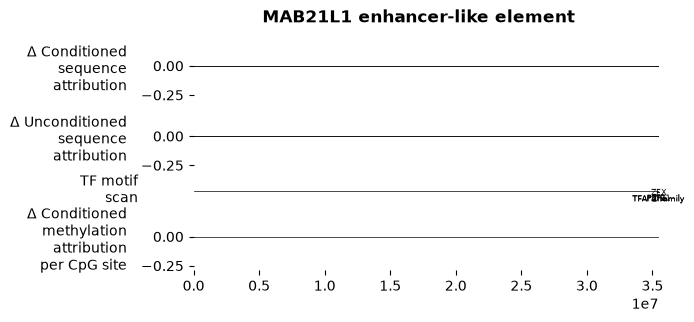

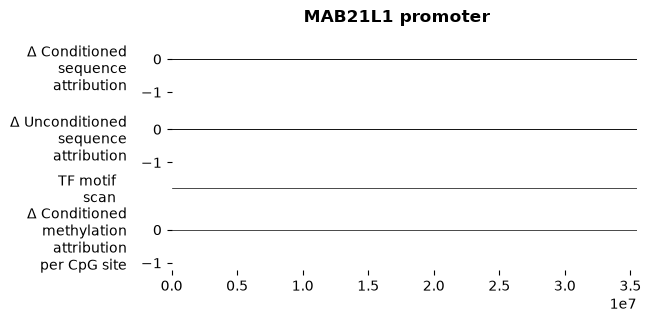

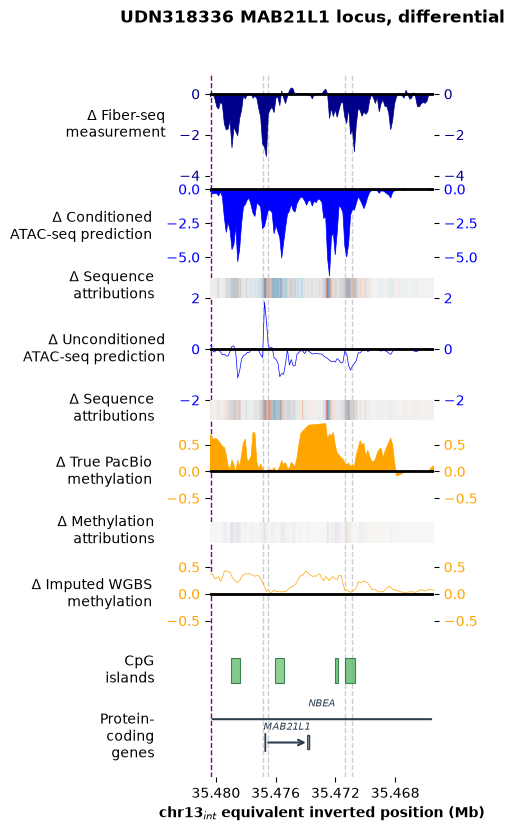

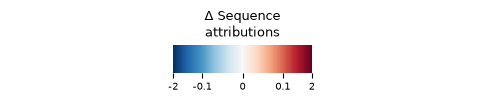

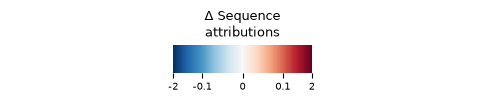

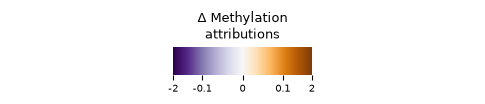

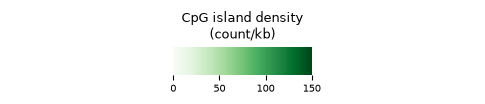

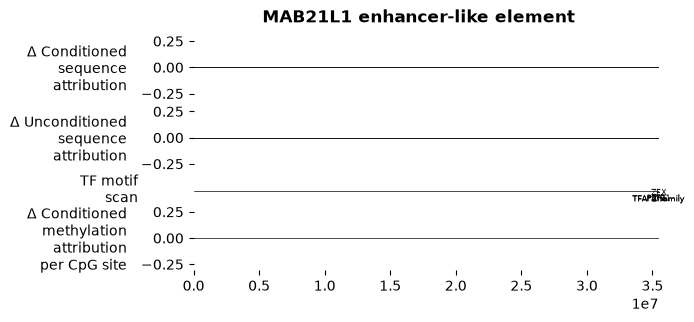

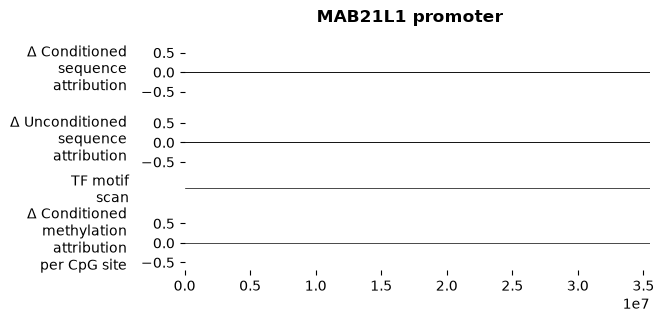

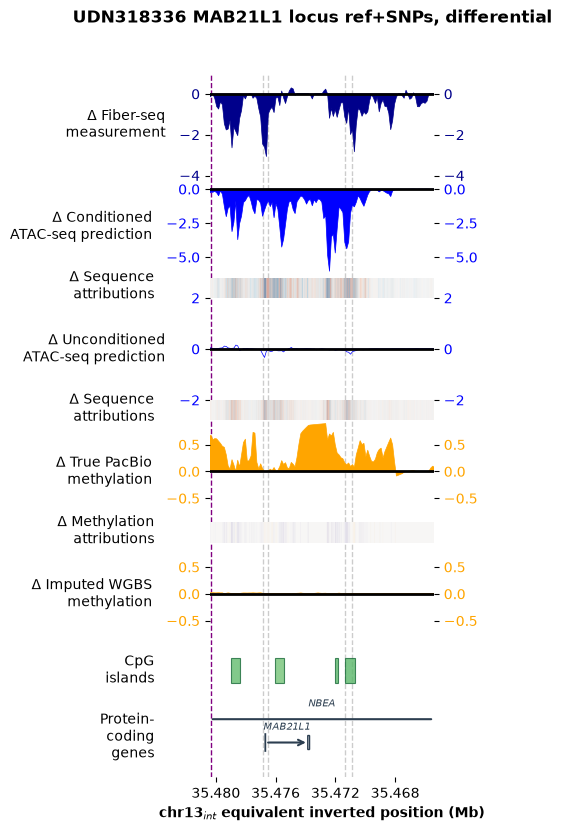

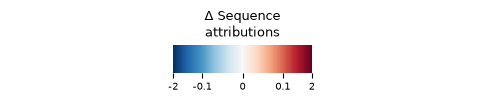

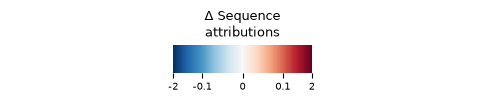

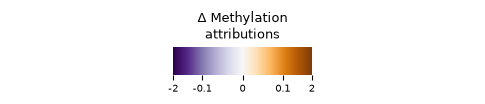

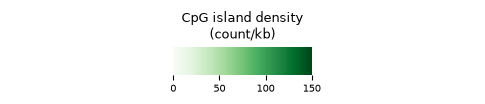

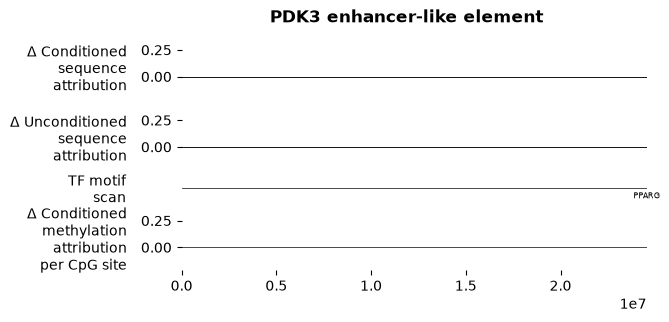

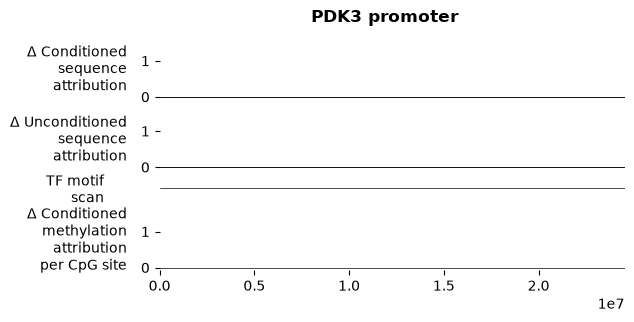

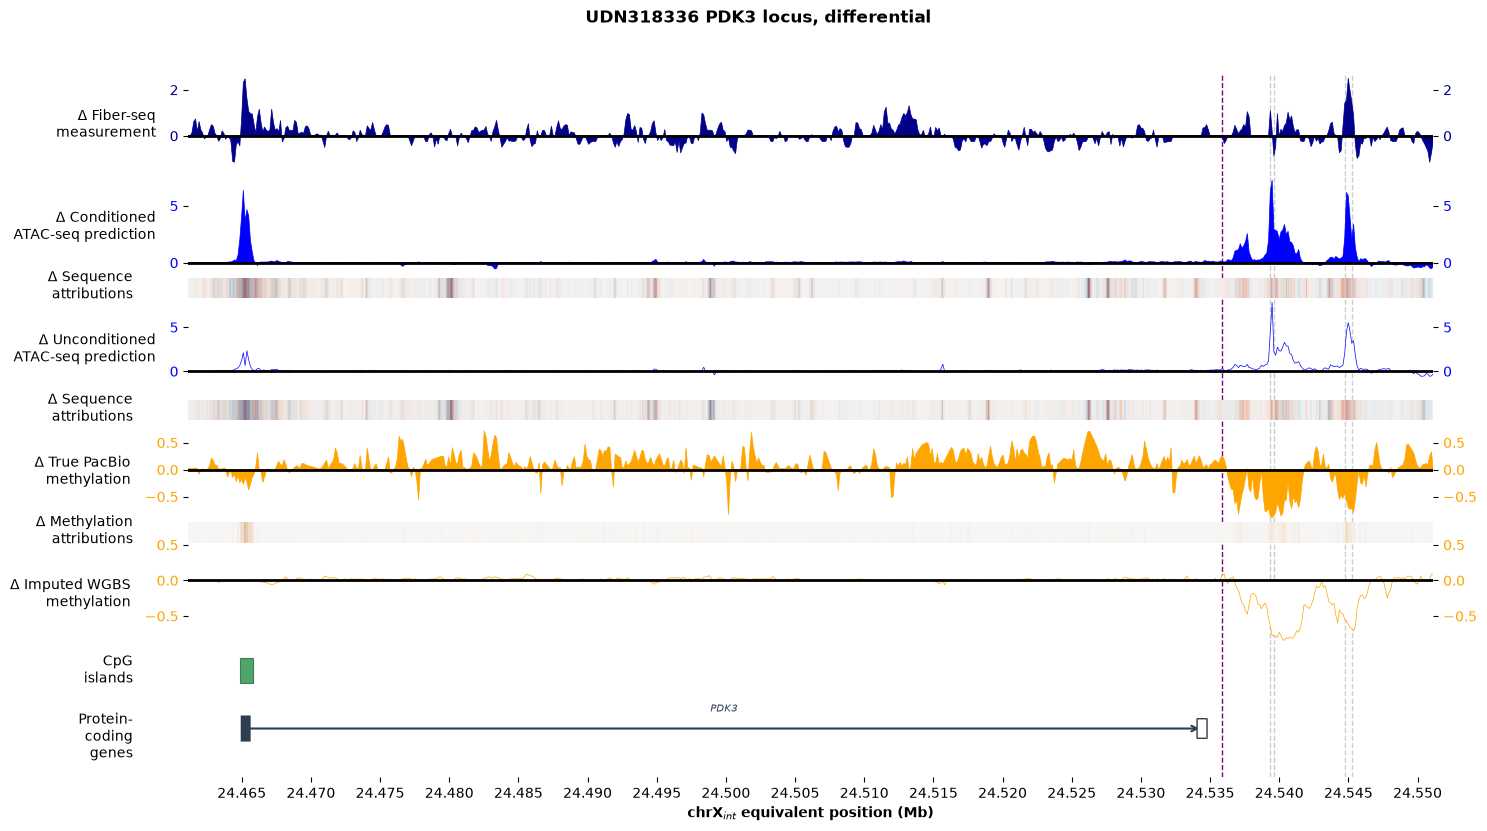

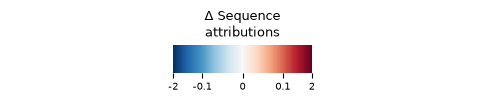

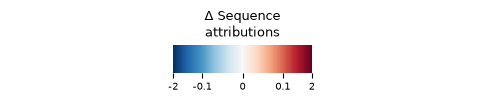

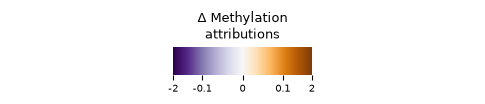

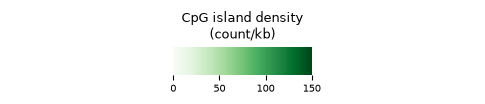

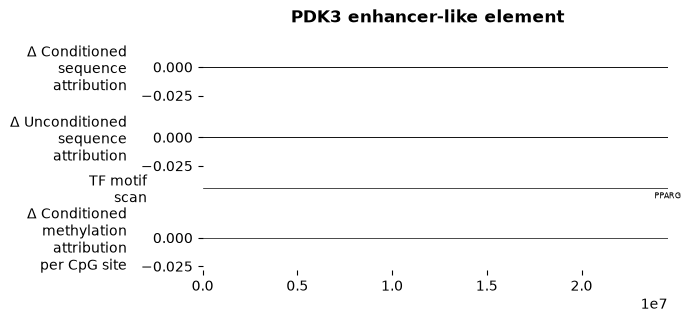

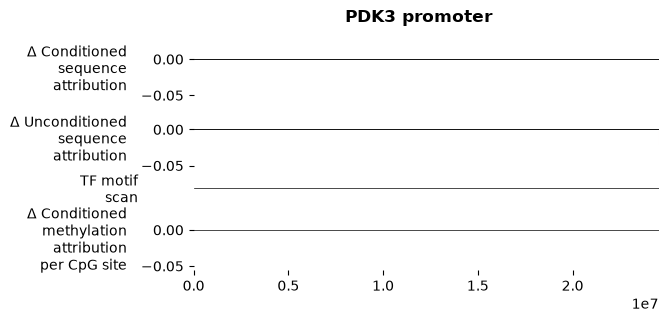

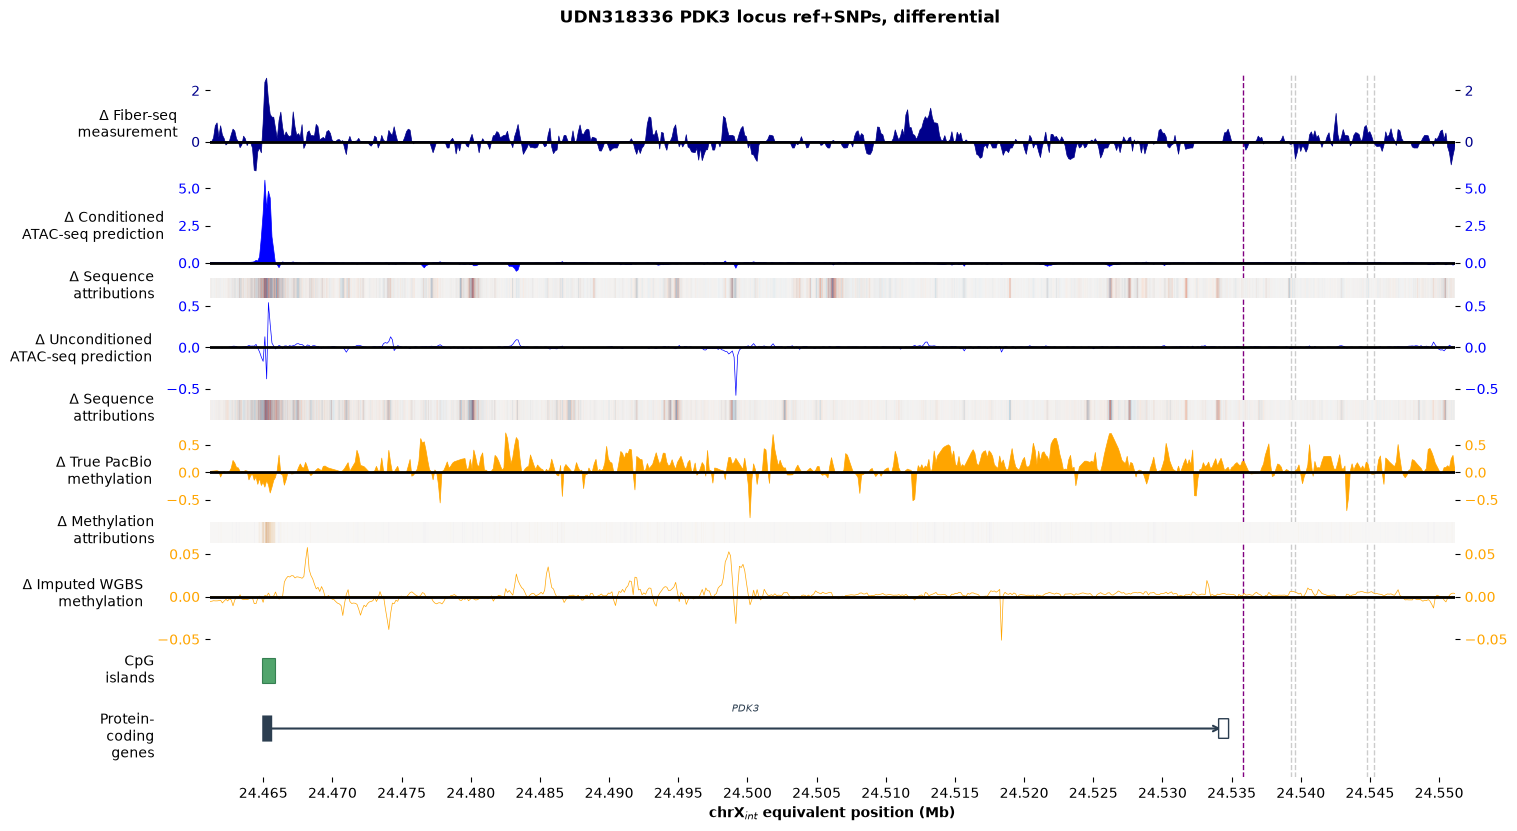

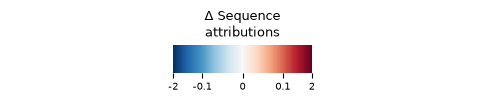

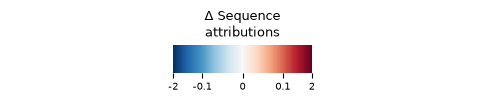

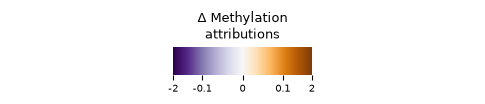

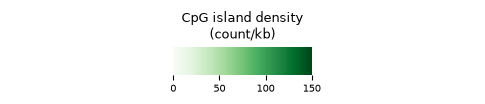

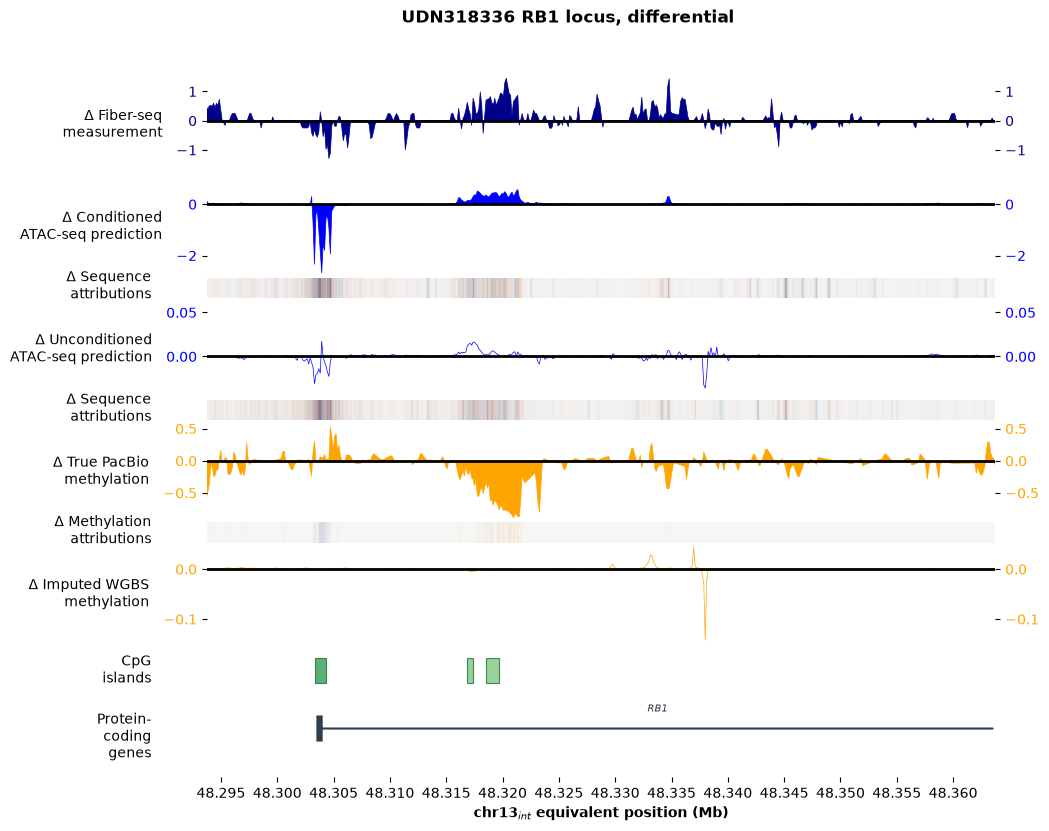

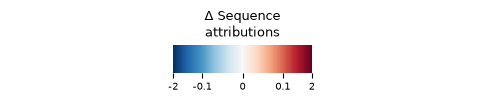

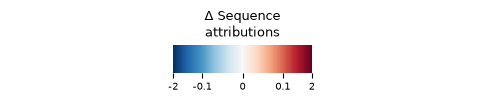

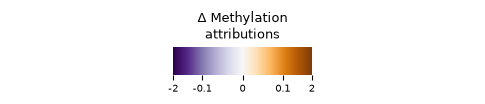

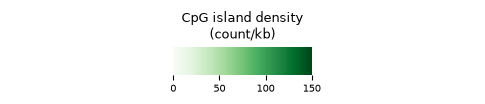

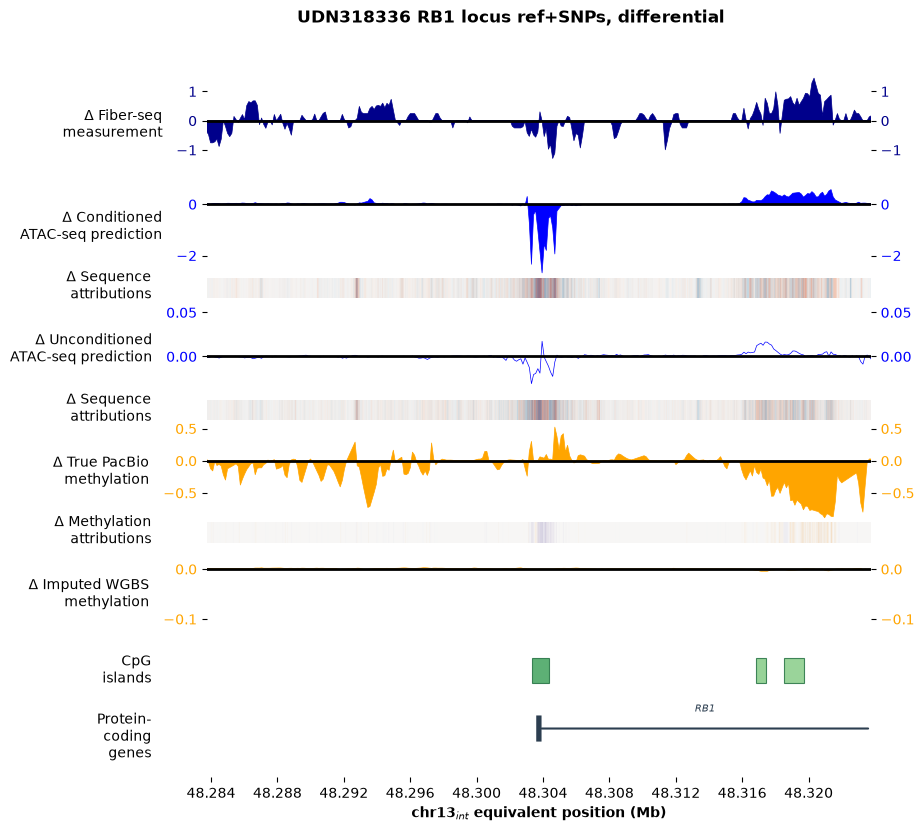

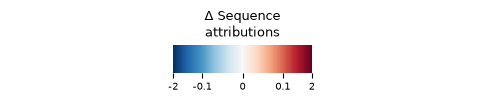

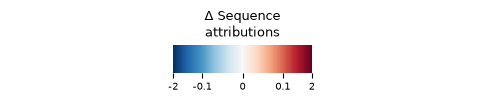

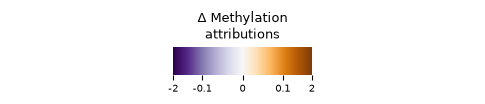

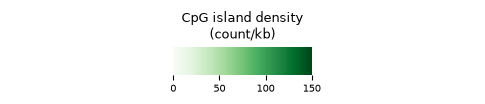

In [6]:
save_pdfs = False
range_around_tss = 1000
enhancer_like_element_range = (35_470_350,35_471_750) #(35_471_122-240,35_471_122+240)
for predict_haplos_dict in [
    # {
    #     "hp1": {
    #         "description": "GM12878 imprinting locus LRRTM1, mono-allelic paternal expression",
    #         "sequence_path": gm_hp1_fasta_file,
    #         "methylation_paths": gm_hp1_methylation_files,
    #         "target_paths": gm_hp1_fiber_files,
    #         "tasks": gm_fiber_tasks,
    #         "chromosome": imprint_chrom,
    #         "start": imprint_tss - 524288 // 2,
    #         "end": imprint_tss + 524288 // 2,
    #         "logo_starts": [imprint_tss - 340],
    #         "logo_ends": [imprint_tss - 90],
    #         "logo_titles":[f"LRRTM1 promoter"],
    #         "methylation_load_kwargs": {"extend_cpg_sites": True, "cpg_values_rescale": 0.01},
    #         "plot_range": 40000,
    #         "ylim_match_sets":[(0,),(1,)],
    #         "ylims_by_set":[(-2,5,),(-0.5,3)],
    #         "target_assay":"Fiber-seq",
    #         "prediction_assay":"Fiber-seq",
    #         "methylation_assay":"PacBio",
    #         "imputed_methylation_assay":"PacBio",
    #     },
    #     "hp2": {
    #         "description": "GM12878 imprinting locus LRRTM1, mono-allelic paternal expression",
    #         "sequence_path": gm_hp2_fasta_file,
    #         "methylation_paths": gm_hp2_methylation_files,
    #         "target_paths": gm_hp2_fiber_files,
    #         "tasks": gm_fiber_tasks,
    #         "chromosome": imprint_chrom,
    #         "start": imprint_tss - 524288 // 2,
    #         "end": imprint_tss + 524288 // 2,
    #         "logo_starts": [imprint_tss - 340],
    #         "logo_ends": [imprint_tss -90],
    #         "methylation_load_kwargs": {"extend_cpg_sites": True, "cpg_values_rescale": 0.01},
    #         "plot_range": 40000, 
    #         "ylim_match_sets":[(0,),(1,)],
    #         "ylims_by_set":[(-2,5,),(-0.5,3)],
    #         "target_assay":"Fiber-seq",
    #         "prediction_assay":"Fiber-seq",
    #         "methylation_assay":"PacBio",
    #         "imputed_methylation_assay":"PacBio",
    #     },
    # },
    # {
    #     "hp1": {
    #         "description": "GM12878 imprinting locus CDH18",
    #         "sequence_path": gm_hp1_fasta_file,
    #         "methylation_paths": gm_hp1_methylation_files,
    #         "target_paths": gm_hp1_fiber_files,
    #         "tasks": gm_fiber_tasks,
    #         "chromosome": "chr5",
    #         "start": 19988200 - 524288 // 2,
    #         "end": 19988200 + 524288 // 2,
    #         "logo_starts":[],
    #         "logo_ends":[],
    #         # "logo_starts": [19988200 - 200],
    #         # "logo_ends": [19988200 + 200],
    #         # "logo_titles":[f"CDH18 promoter"],
    #         "methylation_load_kwargs": {"extend_cpg_sites": True, "cpg_values_rescale": 0.01},
    #         "plot_range": 40000,
    #         # "ylim_match_sets":[(0,),(1,)],
    #         # "ylims_by_set":[(-2,5,),(-0.5,3)],
    #         "target_assay":"Fiber-seq",
    #         "prediction_assay":"Fiber-seq",
    #         "methylation_assay":"PacBio",
    #         "imputed_methylation_assay":"PacBio",
    #     },
    #     "hp2": {
    #         "description": "GM12878 imprinting locus CDH18",
    #         "sequence_path": gm_hp2_fasta_file,
    #         "methylation_paths": gm_hp2_methylation_files,
    #         "target_paths": gm_hp2_fiber_files,
    #         "tasks": gm_fiber_tasks,
    #         "chromosome": "chr5",
    #         "start": 19988200 - 524288 // 2,
    #         "end": 19988200 + 524288 // 2,
    #         "logo_starts":[],
    #         "logo_ends":[],
    #         # "logo_starts": [19988200 - 200],
    #         # "logo_ends": [19988200 + 200],
    #         # "logo_titles":[f"CDH18 promoter"],
    #         "methylation_load_kwargs": {"extend_cpg_sites": True, "cpg_values_rescale": 0.01},
    #         "plot_range": 40000, 
    #         # "ylim_match_sets":[(0,),(1,)],
    #         # "ylims_by_set":[(-2,5,),(-0.5,3)],
    #         "target_assay":"Fiber-seq",
    #         "prediction_assay":"Fiber-seq",
    #         "methylation_assay":"PacBio",
    #         "imputed_methylation_assay":"PacBio",
    #     },
    # },
    # {
    #     "hp1": {
    #         "description": "GM12878 imprinting locus LIN28B",
    #         "sequence_path": gm_hp1_fasta_file,
    #         "methylation_paths": gm_hp1_methylation_files,
    #         "target_paths": gm_hp1_fiber_files,
    #         "tasks": gm_fiber_tasks,
    #         "chromosome": "chr6",
    #         "start": 104957107 - 524288 // 2,
    #         "end": 104957107 + 524288 // 2,
    #         "logo_starts":[],
    #         "logo_ends":[],
    #         # "logo_starts": [104957107 - 200],
    #         # "logo_ends": [104957107 + 200],
    #         # "logo_titles":[f"LIN28B promoter"],
    #         "methylation_load_kwargs": {"extend_cpg_sites": True, "cpg_values_rescale": 0.01},
    #         "plot_range": 40000,
    #         # "ylim_match_sets":[(0,),(1,)],
    #         # "ylims_by_set":[(-2,5,),(-0.5,3)],
    #         "target_assay":"Fiber-seq",
    #         "prediction_assay":"Fiber-seq",
    #         "methylation_assay":"PacBio",
    #         "imputed_methylation_assay":"PacBio",
    #     },
    #     "hp2": {
    #         "description": "GM12878 imprinting locus LIN28B",
    #         "sequence_path": gm_hp2_fasta_file,
    #         "methylation_paths": gm_hp2_methylation_files,
    #         "target_paths": gm_hp2_fiber_files,
    #         "tasks": gm_fiber_tasks,
    #         "chromosome": "chr6",
    #         "start": 104957107 - 524288 // 2,
    #         "end": 104957107 + 524288 // 2,
    #         "logo_starts":[],
    #         "logo_ends":[],
    #         # "logo_starts": [104957107 - 200],
    #         # "logo_ends": [104957107 + 200],
    #         # "logo_titles":[f"LIN28B promoter"],
    #         "methylation_load_kwargs": {"extend_cpg_sites": True, "cpg_values_rescale": 0.01},
    #         "plot_range": 40000, 
    #         # "ylim_match_sets":[(0,),(1,)],
    #         # "ylims_by_set":[(-2,5,),(-0.5,3)],
    #         "target_assay":"Fiber-seq",
    #         "prediction_assay":"Fiber-seq",
    #         "methylation_assay":"PacBio",
    #         "imputed_methylation_assay":"PacBio",
    #     },
    # },
    # {
    #     "hp1": {
    #         "description": "GM12878 imprinting locus CRYBG1",
    #         "sequence_path": gm_hp1_fasta_file,
    #         "methylation_paths": gm_hp1_methylation_files,
    #         "target_paths": gm_hp1_fiber_files,
    #         "tasks": gm_fiber_tasks,
    #         "chromosome": "chr6",
    #         "start": 106360717 - 524288 // 2,
    #         "end": 106360717 + 524288 // 2,
    #         "logo_starts":[],
    #         "logo_ends":[],
    #         # "logo_starts": [106360717 - 200],
    #         # "logo_ends": [106360717 + 200],
    #         # "logo_titles":[f"CRYBG1 promoter"],
    #         "methylation_load_kwargs": {"extend_cpg_sites": True, "cpg_values_rescale": 0.01},
    #         "plot_range": 40000,
    #         # "ylim_match_sets":[(0,),(1,)],
    #         # "ylims_by_set":[(-2,5,),(-0.5,3)],
    #         "target_assay":"Fiber-seq",
    #         "prediction_assay":"Fiber-seq",
    #         "methylation_assay":"PacBio",
    #         "imputed_methylation_assay":"PacBio",
    #     },
    #     "hp2": {
    #         "description": "GM12878 imprinting locus CRYBG1",
    #         "sequence_path": gm_hp2_fasta_file,
    #         "methylation_paths": gm_hp2_methylation_files,
    #         "target_paths": gm_hp2_fiber_files,
    #         "tasks": gm_fiber_tasks,
    #         "chromosome": "chr6",
    #         "start": 106360717 - 524288 // 2,
    #         "end": 106360717 + 524288 // 2,
    #         "logo_starts":[],
    #         "logo_ends":[],
    #         # "logo_starts": [106360717 - 200],
    #         # "logo_ends": [106360717 + 200],
    #         # "logo_titles":[f"CRYBG1 promoter"],
    #         "methylation_load_kwargs": {"extend_cpg_sites": True, "cpg_values_rescale": 0.01},
    #         "plot_range": 40000, 
    #         # "ylim_match_sets":[(0,),(1,)],
    #         # "ylims_by_set":[(-2,5,),(-0.5,3)],
    #         "target_assay":"Fiber-seq",
    #         "prediction_assay":"Fiber-seq",
    #         "methylation_assay":"PacBio",
    #         "imputed_methylation_assay":"PacBio",
    #     },
    # },
    # {
    #     "hp1": {
    #         "description": "GM12878 imprinting locus PLAGL1",
    #         "sequence_path": gm_hp1_fasta_file,
    #         "methylation_paths": gm_hp1_methylation_files,
    #         "target_paths": gm_hp1_fiber_files,
    #         "tasks": gm_fiber_tasks,
    #         "chromosome": "chr6",
    #         "start": 144008259 - 524288 // 2,
    #         "end": 144008259 + 524288 // 2,
    #         "logo_starts":[],
    #         "logo_ends":[],
    #         # "logo_starts": [144008259 - 200],
    #         # "logo_ends": [144008259 + 200],
    #         # "logo_titles":[f"PLAGL1 promoter"],
    #         "methylation_load_kwargs": {"extend_cpg_sites": True, "cpg_values_rescale": 0.01},
    #         "plot_range": 40000,
    #         # "ylim_match_sets":[(0,),(1,)],
    #         # "ylims_by_set":[(-2,5,),(-0.5,3)],
    #         "target_assay":"Fiber-seq",
    #         "prediction_assay":"Fiber-seq",
    #         "methylation_assay":"PacBio",
    #         "imputed_methylation_assay":"PacBio",
    #     },
    #     "hp2": {
    #         "description": "GM12878 imprinting locus PLAGL1",
    #         "sequence_path": gm_hp2_fasta_file,
    #         "methylation_paths": gm_hp2_methylation_files,
    #         "target_paths": gm_hp2_fiber_files,
    #         "tasks": gm_fiber_tasks,
    #         "chromosome": "chr6",
    #         "start": 144008259 - 524288 // 2,
    #         "end": 144008259 + 524288 // 2,
    #         "logo_starts":[],
    #         "logo_ends":[],
    #         # "logo_starts": [144008259 - 200],
    #         # "logo_ends": [144008259 + 200],
    #         # "logo_titles":[f"PLAGL1 promoter"],
    #         "methylation_load_kwargs": {"extend_cpg_sites": True, "cpg_values_rescale": 0.01},
    #         "plot_range": 40000, 
    #         # "ylim_match_sets":[(0,),(1,)],
    #         # "ylims_by_set":[(-2,5,),(-0.5,3)],
    #         "target_assay":"Fiber-seq",
    #         "prediction_assay":"Fiber-seq",
    #         "methylation_assay":"PacBio",
    #         "imputed_methylation_assay":"PacBio",
    #     },
    # },
    # {
    #     "hp1": {
    #         "description": "GM12878 imprinting locus IGF2R",
    #         "sequence_path": gm_hp1_fasta_file,
    #         "methylation_paths": gm_hp1_methylation_files,
    #         "target_paths": gm_hp1_fiber_files,
    #         "tasks": gm_fiber_tasks,
    #         "chromosome": "chr6",
    #         "start": 159969082 - 524288 // 2,
    #         "end": 159969082 + 524288 // 2,
    #         "logo_starts":[],
    #         "logo_ends":[],
    #         # "logo_starts": [159969082 - 200],
    #         # "logo_ends": [159969082 + 200],
    #         # "logo_titles":[f"IGF2R promoter"],
    #         "methylation_load_kwargs": {"extend_cpg_sites": True, "cpg_values_rescale": 0.01},
    #         "plot_range": 40000,
    #         # "ylim_match_sets":[(0,),(1,)],
    #         # "ylims_by_set":[(-2,5,),(-0.5,3)],
    #         "target_assay":"Fiber-seq",
    #         "prediction_assay":"Fiber-seq",
    #         "methylation_assay":"PacBio",
    #         "imputed_methylation_assay":"PacBio",
    #     },
    #     "hp2": {
    #         "description": "GM12878 imprinting locus IGF2R",
    #         "sequence_path": gm_hp2_fasta_file,
    #         "methylation_paths": gm_hp2_methylation_files,
    #         "target_paths": gm_hp2_fiber_files,
    #         "tasks": gm_fiber_tasks,
    #         "chromosome": "chr6",
    #         "start": 159969082 - 524288 // 2,
    #         "end": 159969082 + 524288 // 2,
    #         "logo_starts":[],
    #         "logo_ends":[],
    #         # "logo_starts": [159969082 - 200],
    #         # "logo_ends": [159969082 + 200],
    #         # "logo_titles":[f"IGF2R promoter"],
    #         "methylation_load_kwargs": {"extend_cpg_sites": True, "cpg_values_rescale": 0.01},
    #         "plot_range": 40000, 
    #         # "ylim_match_sets":[(0,),(1,)],
    #         # "ylims_by_set":[(-2,5,),(-0.5,3)],
    #         "target_assay":"Fiber-seq",
    #         "prediction_assay":"Fiber-seq",
    #         "methylation_assay":"PacBio",
    #         "imputed_methylation_assay":"PacBio",
    #     },
    # },
    # {
    #     "hp1": {
    #         "description": "GM12878 imprinting locus PURG",
    #         "sequence_path": gm_hp1_fasta_file,
    #         "methylation_paths": gm_hp1_methylation_files,
    #         "target_paths": gm_hp1_fiber_files,
    #         "tasks": gm_fiber_tasks,
    #         "chromosome": "chr8",
    #         "start": 31033356 - 524288 // 2,
    #         "end": 31033356 + 524288 // 2,
    #         "logo_starts":[],
    #         "logo_ends":[],
    #         # "logo_starts": [31033356 - 200],
    #         # "logo_ends": [31033356 + 200],
    #         # "logo_titles":[f"PURG promoter"],
    #         "methylation_load_kwargs": {"extend_cpg_sites": True, "cpg_values_rescale": 0.01},
    #         "plot_range": 40000,
    #         # "ylim_match_sets":[(0,),(1,)],
    #         # "ylims_by_set":[(-2,5,),(-0.5,3)],
    #         "target_assay":"Fiber-seq",
    #         "prediction_assay":"Fiber-seq",
    #         "methylation_assay":"PacBio",
    #         "imputed_methylation_assay":"PacBio",
    #     },
    #     "hp2": {
    #         "description": "GM12878 imprinting locus PURG",
    #         "sequence_path": gm_hp2_fasta_file,
    #         "methylation_paths": gm_hp2_methylation_files,
    #         "target_paths": gm_hp2_fiber_files,
    #         "tasks": gm_fiber_tasks,
    #         "chromosome": "chr8",
    #         "start": 31033356 - 524288 // 2,
    #         "end": 31033356 + 524288 // 2,
    #         "logo_starts":[],
    #         "logo_ends":[],
    #         # "logo_starts": [31033356 - 200],
    #         # "logo_ends": [31033356 + 200],
    #         # "logo_titles":[f"PURG promoter"],
    #         "methylation_load_kwargs": {"extend_cpg_sites": True, "cpg_values_rescale": 0.01},
    #         "plot_range": 40000, 
    #         # "ylim_match_sets":[(0,),(1,)],
    #         # "ylims_by_set":[(-2,5,),(-0.5,3)],
    #         "target_assay":"Fiber-seq",
    #         "prediction_assay":"Fiber-seq",
    #         "methylation_assay":"PacBio",
    #         "imputed_methylation_assay":"PacBio",
    #     },
    # },
    # {
    #     "hp1": {
    #         "description": "GM12878 imprinting locus PHPT1",
    #         "sequence_path": gm_hp1_fasta_file,
    #         "methylation_paths": gm_hp1_methylation_files,
    #         "target_paths": gm_hp1_fiber_files,
    #         "tasks": gm_fiber_tasks,
    #         "chromosome": "chr9",
    #         "start": 136849409 - 524288 // 2,
    #         "end": 136849409 + 524288 // 2,
    #         "logo_starts":[],
    #         "logo_ends":[],
    #         "methylation_load_kwargs": {"extend_cpg_sites": True, "cpg_values_rescale": 0.01},
    #         "plot_range": 40000,
    #         # "ylim_match_sets":[(0,),(1,)],
    #         # "ylims_by_set":[(-2,5,),(-0.5,3)],
    #         "target_assay":"Fiber-seq",
    #         "prediction_assay":"Fiber-seq",
    #         "methylation_assay":"PacBio",
    #         "imputed_methylation_assay":"PacBio",
    #     },
    #     "hp2": {
    #         "description": "GM12878 imprinting locus PHPT1",
    #         "sequence_path": gm_hp2_fasta_file,
    #         "methylation_paths": gm_hp2_methylation_files,
    #         "target_paths": gm_hp2_fiber_files,
    #         "tasks": gm_fiber_tasks,
    #         "chromosome": "chr9",
    #         "start": 136849409 - 524288 // 2,
    #         "end": 136849409 + 524288 // 2,
    #         "logo_starts":[],
    #         "logo_ends":[],
    #         "methylation_load_kwargs": {"extend_cpg_sites": True, "cpg_values_rescale": 0.01},
    #         "plot_range": 40000, 
    #         # "ylim_match_sets":[(0,),(1,)],
    #         # "ylims_by_set":[(-2,5,),(-0.5,3)],
    #         "target_assay":"Fiber-seq",
    #         "prediction_assay":"Fiber-seq",
    #         "methylation_assay":"PacBio",
    #         "imputed_methylation_assay":"PacBio",
    #     },
    # },
    {
        "reference_hp": "hp2", # reference for shared coords
        "hp1": {
            "description":"UDN318336 MAB21L1 locus, differential",
            "sequence_path":udn_hp1_fusion_fasta_file,
            "methylation_paths":udn_hp1_fusion_methylation_files,
            "target_paths":udn_hp1_fusion_fiber_files,
            "manual_targets_normalization":udn_hp1_manual_counts_normalizations,
            "tasks":(46,),
            "chromosome":"der13_fwd",
            "start":35480299 - 524288//2 - 4900,
            "end":35480299 + 524288//2 - 4900,
            "logo_starts":[35_471_122-240,35_476_689-150],
            "logo_ends":[35_471_122+240,35_476_689+150],
            "logo_titles":["MAB21L1 enhancer-like element","MAB21L1 promoter",],
            "methylation_load_kwargs":{"extend_cpg_sites": True, "cpg_values_rescale": 0.01},
            "plot_range":15_000,
            "flag_point":35480299,
            "ylim_match_sets":[(0,),(1,),(3,),(5,7)],
            "ylims_by_set":[(-4,1),(-6.5,1),(-2,2),(-.95,.95)],
            "chromosome_label":r"chr13$_{int}$ equivalent inverted",
            "figsize":(2.7,8),
            "plot_offset":-2500,
            "flip_x":True,
            "target_assay":"Fiber-seq",
            "prediction_assay":"ATAC-seq",
            "methylation_assay":"PacBio",
            "imputed_methylation_assay":"WGBS",
            "differential_counts_regions":[enhancer_like_element_range,(35_476_689-range_around_tss,35_476_689+range_around_tss)],
        },
        "hp2": {
            "description":"UDN318336 MAB21L1 locus, differential",
            "sequence_path":udn_hp2_fasta_file,
            "methylation_paths":udn_hp2_methylation_files,
            "target_paths":udn_hp2_fiber_files,
            "tasks":(46,),
            "chromosome":"chr13",
            "start":35480299 - 524288//2 - 4900,
            "end":35480299 + 524288//2 - 4900,
            "logo_starts":[],
            "logo_ends":[],
            "logo_starts":[35_471_122-240,35_476_689-150],
            "logo_ends":[35_471_122+240,35_476_689+150],
            "logo_titles":["MAB21L1 enhancer-like element","MAB21L1 promoter",],
            "methylation_load_kwargs":{"extend_cpg_sites": True, "cpg_values_rescale": 0.01},
            "plot_range":15_000,
            "flag_point":35480299,
            "ylim_match_sets":[(0,),(1,),(3,),(5,7)],
            "ylims_by_set":[(-4,1),(-6.5,1),(-2,2),(-.95,.95)],
            "chromosome_label":r"chr13$_{int}$ equivalent inverted",
            "figsize":(2.7,8),
            "plot_offset":-2500,
            "flip_x":True,
            "target_assay":"Fiber-seq",
            "prediction_assay":"ATAC-seq",
            "methylation_assay":"PacBio",
            "imputed_methylation_assay":"WGBS",
            "differential_counts_regions":[enhancer_like_element_range,(35_476_689-range_around_tss,35_476_689+range_around_tss)],
        },  
    },
    {
        "hp1": {
            "description":"UDN318336 MAB21L1 locus ref+SNPs, differential",
            "sequence_path":udn_hp1_fasta_file,
            "methylation_paths":udn_hp1_methylation_files,
            "target_paths":udn_hp1_fiber_files,
            "tasks":(46,),
            "chromosome":"chr13",
            "start":35480299 - 524288//2 - 4900,
            "end":35480299 + 524288//2 - 4900,
            "logo_starts":[35_471_122-240,35_476_689-150],
            "logo_ends":[35_471_122+240,35_476_689+150],
            "logo_titles":["MAB21L1 enhancer-like element","MAB21L1 promoter",],
            "methylation_load_kwargs":{"extend_cpg_sites": True, "cpg_values_rescale": 0.01},
            "plot_range":15_000,
            "flag_point":35480299,
            "ylim_match_sets":[(0,),(1,),(3,),(5,7)],
            "ylims_by_set":[(-4,1),(-6.5,1),(-2,2),(-.95,.95)],
            "chromosome_label":r"chr13$_{int}$ equivalent inverted",
            "figsize":(2.7,8),
            "plot_offset":-2500,
            "flip_x":True,
            "target_assay":"Fiber-seq",
            "prediction_assay":"ATAC-seq",
            "methylation_assay":"PacBio",
            "imputed_methylation_assay":"WGBS",
            "differential_counts_regions":[enhancer_like_element_range,(35_476_689-range_around_tss,35_476_689+range_around_tss)],
        },
        "hp2": {
            "description":"UDN318336 MAB21L1 locus ref+SNPs, differential",
            "sequence_path":udn_hp2_fasta_file,
            "methylation_paths":udn_hp2_methylation_files,
            "target_paths":udn_hp2_fiber_files,
            "tasks":(46,),
            "chromosome":"chr13",
            "start":35480299 - 524288//2 - 4900,
            "end":35480299 + 524288//2 - 4900,
            "logo_starts":[35_471_122-240,35_476_689-150],
            "logo_ends":[35_471_122+240,35_476_689+150],
            "logo_titles":["MAB21L1 enhancer-like element","MAB21L1 promoter",],
            "methylation_load_kwargs":{"extend_cpg_sites": True, "cpg_values_rescale": 0.01},
            "plot_range":15_000,
            "flag_point":35480299,
            "ylim_match_sets":[(0,),(1,),(3,),(5,7)],
            "ylims_by_set":[(-4,1),(-6.5,1),(-2,2),(-.95,.95)],
            "chromosome_label":r"chr13$_{int}$ equivalent inverted",
            "figsize":(2.7,8),
            "plot_offset":-2500,
            "flip_x":True,
            "target_assay":"Fiber-seq",
            "prediction_assay":"ATAC-seq",
            "methylation_assay":"PacBio",
            "imputed_methylation_assay":"WGBS",
            "differential_counts_regions":[enhancer_like_element_range,(35_476_689-range_around_tss,35_476_689+range_around_tss)],
        },  
    },
    {
        "reference_hp": "hp2", # reference for shared coords
        "hp1": {
            "description":"UDN318336 PDK3 locus, differential",
            "sequence_path":udn_hp1_fusion_fasta_file,
            "methylation_paths":udn_hp1_fusion_methylation_files,
            "target_paths":udn_hp1_fusion_fiber_files,
            "manual_targets_normalization":udn_hp1_manual_counts_normalizations,
            "tasks":(46,),
            "chromosome":"der13_rev",
            "start":24_465_286 - 524288//2 + 45556 - 4700, #34500 - 25000,
            "end":24_465_286 + 524288//2 + 45556 - 4700, #34500 - 25000,
            "logo_starts":[],
            "logo_ends":[],
            "logo_starts":[24_545_019-240, 24_539_452-150],
            "logo_ends":[24_545_019+240, 24_539_452+150],
            "logo_titles":["PDK3 enhancer-like element","PDK3 promoter",],
            "methylation_load_kwargs":{"extend_cpg_sites": True, "cpg_values_rescale": 0.01},
            "plot_range":90_000,
            "flag_point":24_535_842,
            # "ylim_match_sets":[(0,),(1,3),(5,7)],
            # "ylims_by_set":[(-4,4),(-6.5,6.5),(-.95,.95)],
            "chromosome_label":r"chrX$_{int}$ equivalent",
            "figsize":(15,8),
            "plot_offset":-0000,
            "target_assay":"Fiber-seq",
            "prediction_assay":"ATAC-seq",
            "methylation_assay":"PacBio",
            "imputed_methylation_assay":"WGBS",
            "differential_counts_regions":[(24_465_286-range_around_tss, 24_465_286+range_around_tss),(24_545_019-240, 24_545_019+240),(24_539_452-500, 24_539_452+500)],
        },
        "hp2": {
            "description":"UDN318336 PDK3 locus, differential",
            "sequence_path":udn_hp2_fasta_file,
            "methylation_paths":udn_hp2_methylation_files,
            "target_paths":udn_hp2_fiber_files,
            "tasks":(46,),
            "chromosome":"chrX",
            "start":24_465_286 - 524288//2 + 45556 - 4700, #34500 - 25000,
            "end":24_465_286 + 524288//2 + 45556 - 4700, #34500 - 25000,
            "logo_starts":[],
            "logo_ends":[],
            "logo_starts":[24_545_019-240, 24_539_452-150],
            "logo_ends":[24_545_019+240, 24_539_452+150],
            "logo_titles":["PDK3 enhancer-like element","PDK3 promoter",],
            "methylation_load_kwargs":{"extend_cpg_sites": True, "cpg_values_rescale": 0.01},
            "plot_range":90_000,
            "flag_point":24_535_842,
            # "ylim_match_sets":[(0,),(1,3),(5,7)],
            # "ylims_by_set":[(-4,4),(-6.5,6.5),(-.95,.95)],
            "chromosome_label":r"chrX$_{int}$ equivalent",
            "figsize":(15,8),
            "plot_offset":-0000,
            "target_assay":"Fiber-seq",
            "prediction_assay":"ATAC-seq",
            "methylation_assay":"PacBio",
            "imputed_methylation_assay":"WGBS",
            "differential_counts_regions":[(24_465_286-range_around_tss, 24_465_286+range_around_tss),(24_545_019-240, 24_545_019+240),(24_539_452-range_around_tss, 24_539_452+range_around_tss)],
        },  
    },
    {
        "hp1": {
            "description":"UDN318336 PDK3 locus ref+SNPs, differential",
            "sequence_path":udn_hp1_fasta_file,
            "methylation_paths":udn_hp1_methylation_files,
            "target_paths":udn_hp1_fiber_files,
            "tasks":(46,),
            "chromosome":"chrX",
            "start":24_465_286 - 524288//2 + 45556 - 4700, #34500 - 25000,
            "end":24_465_286 + 524288//2 + 45556 - 4700, #34500 - 25000,
            "logo_starts":[24_545_019-240, 24_539_452-150],
            "logo_ends":[24_545_019+240, 24_539_452+150],
            "logo_titles":["PDK3 enhancer-like element","PDK3 promoter",],
            "methylation_load_kwargs":{"extend_cpg_sites": True, "cpg_values_rescale": 0.01},
            "plot_range":90_000,
            "flag_point":24_535_842,
            # "ylim_match_sets":[(0,),(1,3),(5,7)],
            # "ylims_by_set":[(-4,4),(-6.5,6.5),(-.95,.95)],
            "chromosome_label":r"chrX$_{int}$ equivalent",
            "figsize":(15,8),
            "plot_offset":-0000,
            "target_assay":"Fiber-seq",
            "prediction_assay":"ATAC-seq",
            "methylation_assay":"PacBio",
            "imputed_methylation_assay":"WGBS",
            "differential_counts_regions":[(24_465_286-range_around_tss, 24_465_286+range_around_tss),(24_545_019-240, 24_545_019+240),(24_539_452-range_around_tss, 24_539_452+range_around_tss)],
        },   
        "hp2": {
            "description":"UDN318336 PDK3 locus ref+SNPs, differential",
            "sequence_path":udn_hp2_fasta_file,
            "methylation_paths":udn_hp2_methylation_files,
            "target_paths":udn_hp2_fiber_files,
            "tasks":(46,),
            "chromosome":"chrX",
            "start":24_465_286 - 524288//2 + 45556 - 4700, #34500 - 25000,
            "end":24_465_286 + 524288//2 + 45556 - 4700, #34500 - 25000,
            "logo_starts":[24_545_019-240, 24_539_452-150],
            "logo_ends":[24_545_019+240, 24_539_452+150],
            "logo_titles":["PDK3 enhancer-like element","PDK3 promoter",],
            "methylation_load_kwargs":{"extend_cpg_sites": True, "cpg_values_rescale": 0.01},
            "plot_range":90_000,
            "flag_point":24_535_842,
            # "ylim_match_sets":[(0,),(1,3),(5,7)],
            # "ylims_by_set":[(-4,4),(-6.5,6.5),(-.95,.95)],
            "chromosome_label":r"chrX$_{int}$ equivalent",
            "figsize":(15,8),
            "plot_offset":-0000,
            "target_assay":"Fiber-seq",
            "prediction_assay":"ATAC-seq",
            "methylation_assay":"PacBio",
            "imputed_methylation_assay":"WGBS",
            "differential_counts_regions":[(24_465_286-range_around_tss, 24_465_286+range_around_tss),(24_545_019-240, 24_545_019+240),(24_539_452-range_around_tss, 24_539_452+range_around_tss)],
        },   
    },
    {
        "reference_hp":"hp2", # reference for shared coords
        "hp1": {
            "description":"UDN318336 RB1 locus, differential",
            "sequence_path":udn_hp1_fusion_fasta_file,
            "methylation_paths":udn_hp1_fusion_methylation_files,
            "target_paths":udn_hp1_fusion_fiber_files,
            "manual_targets_normalization":udn_hp1_manual_counts_normalizations,
            "tasks":(46,),
            "chromosome":"derX_rev",
            "start":convert_chr13_to_derX_rev(48_303_751) - 524288//2,
            "end":convert_chr13_to_derX_rev(48_303_751) + 524288//2,
            "logo_starts":[],
            "logo_ends":[],
            # "logo_starts":[48_303_751-200,48_319_000],
            # "logo_ends":[48_303_751+00,48_319_200],
            "methylation_load_kwargs":{"extend_cpg_sites": True, "cpg_values_rescale": 0.01},
            "plot_range":70_000,
            "ylim_match_sets":[],
            "chromosome_label":r"chr13$_{int}$ equivalent",
            "plot_offset":25_000,
            "figsize":(9.5,8),
            "target_assay":"Fiber-seq",
            "prediction_assay":"ATAC-seq",
            "methylation_assay":"PacBio",
            "imputed_methylation_assay":"WGBS",
            "differential_counts_regions":[(convert_chr13_to_derX_rev(48_303_751)-range_around_tss,convert_chr13_to_derX_rev(48_303_751)+range_around_tss),],
        },
        "hp2": {
            "description":"UDN318336 RB1 locus, differential",
            "sequence_path":udn_hp2_fasta_file,
            "methylation_paths":udn_hp2_methylation_files,
            "target_paths":udn_hp2_fiber_files,
            "tasks":(46,),
            "chromosome":"chr13",
            "start":48_303_751 - 524288//2,
            "end":48_303_751 + 524288//2,
            "logo_starts":[],
            "logo_ends":[],
            # "logo_starts":[48_303_751-200,48_319_000],
            # "logo_ends":[48_303_751+00,48_319_200],
            "methylation_load_kwargs":{"extend_cpg_sites": True, "cpg_values_rescale": 0.01},
            "plot_range":70_000,
            "ylim_match_sets":[],
            "chromosome_label":r"chr13$_{int}$ equivalent",
            "plot_offset":25_000,
            "figsize":(9.5,8),
            "target_assay":"Fiber-seq",
            "prediction_assay":"ATAC-seq",
            "methylation_assay":"PacBio",
            "imputed_methylation_assay":"WGBS",
            "differential_counts_regions":[(48_303_751-range_around_tss,48_303_751+range_around_tss),],
        },  
    },
    {
        "hp1": {
            "description":"UDN318336 RB1 locus ref+SNPs, differential",
            "sequence_path":udn_hp1_fasta_file,
            "methylation_paths":udn_hp1_methylation_files,
            "target_paths":udn_hp1_fiber_files,
            "tasks":(46,),
            "chromosome":"chr13",
            "start":48_303_751 - 524288//2,
            "end":48_303_751 + 524288//2,
            "logo_starts":[],
            "logo_ends":[],
            # "logo_starts":[48_303_751-200,48_319_000],
            # "logo_ends":[48_303_751+00,48_319_200],
            "methylation_load_kwargs":{"extend_cpg_sites": True, "cpg_values_rescale": 0.01},
            "plot_range":40_000,
            "ylim_match_sets":[],
            "chromosome_label":r"chr13$_{int}$ equivalent",
            "target_assay":"Fiber-seq",
            "prediction_assay":"ATAC-seq",
            "methylation_assay":"PacBio",
            "imputed_methylation_assay":"WGBS",
            "differential_counts_regions":[(48_303_751-range_around_tss,48_303_751+range_around_tss),],
        },
        "hp2": {
            "description":"UDN318336 RB1 locus ref+SNPs, differential",
            "sequence_path":udn_hp2_fasta_file,
            "methylation_paths":udn_hp2_methylation_files,
            "target_paths":udn_hp2_fiber_files,
            "tasks":(46,),
            "chromosome":"chr13",
            "start":48_303_751 - 524288//2,
            "end":48_303_751 + 524288//2,
            "logo_starts":[],
            "logo_ends":[],
            # "logo_starts":[48_303_751-200,48_319_000],
            # "logo_ends":[48_303_751+00,48_319_200],
            "methylation_load_kwargs":{"extend_cpg_sites": True, "cpg_values_rescale": 0.01},
            "plot_range":40_000,
            "ylim_match_sets":[],
            "chromosome_label":r"chr13$_{int}$ equivalent",
            "target_assay":"Fiber-seq",
            "prediction_assay":"ATAC-seq",
            "methylation_assay":"PacBio",
            "imputed_methylation_assay":"WGBS",
            "differential_counts_regions":[(48_303_751-range_around_tss,48_303_751+range_around_tss),],
        },  
    },
]:
    # Set hp1 to use as reference for shared coordinates (chromosome, start, end, logo, plot_range) -- default hp1 but can be overridden by "reference_hp" key
    if "reference_hp" in predict_haplos_dict:
        ref = predict_haplos_dict[predict_haplos_dict["reference_hp"]]
    else:
        ref = predict_haplos_dict["hp1"]
    print(f"Running {ref['description']} at {ref['chromosome']}:{ref['start']}-{ref['end']}...")

    # ---- Run predictions for both haplotypes ----
    results = {}
    for hp_key in ["hp1", "hp2"]:
        pd_ = predict_haplos_dict[hp_key]
        flag_point = pd_.get("flag_point", None)
        common_kwargs = dict(
            chromosome=pd_["chromosome"],
            start=pd_["start"],
            end=pd_["end"],
            sequence_path=pd_["sequence_path"],
            methylation_paths=pd_["methylation_paths"],
            methylation_load_kwargs=pd_.get("methylation_load_kwargs", {}),
        )
        attr_common = dict(
            capture_attributions=True,
            attribution_peak_kwargs={"peak_threshold": None, "min_peak_distance_bins": 5},
            attribution_kwargs=dict(n_steps=5, internal_batch_size=1),
        )

        cond_seq = conditioned_predictor.predict_locus(
            **common_kwargs, **attr_common,
            attribution_baseline_kwargs=dict(
                attribution_baseline_transform=seq_baseline,
                attribution_baselines_per_sample=baselines_per_sample,
            ),
        )
        cond_methyl = conditioned_predictor.predict_locus(
            **common_kwargs, **attr_common,
            attribution_baseline_kwargs=dict(
                attribution_baseline_transform=methyl_baseline,
                attribution_baselines_per_sample=baselines_per_sample,
            ),
        )
        uncond_seq = unconditioned_predictor.predict_locus(
            **common_kwargs, **attr_common,
            attribution_baseline_kwargs=dict(
                attribution_baseline_transform=seq_baseline,
                attribution_baselines_per_sample=baselines_per_sample,
            ),
        )
        if "manual_targets_normalization" in pd_:
            scale_targets = 1 / pd_["manual_targets_normalization"]
            normalize_per_auto = None
        else:
            scale_targets = 1
            normalize_per_auto = 1e9
        targets = scale_targets*conditioned_predictor.load_targets(
            chromosome=pd_["chromosome"],
            start=pd_["start"],
            end=pd_["end"],
            target_paths=pd_["target_paths"],
            normalize_counts_per=normalize_per_auto,
            softclip_threshold=32,
        )

        results[hp_key] = {
            "cond_seq": cond_seq,
            "cond_methyl": cond_methyl,
            "uncond_seq": uncond_seq,
            "targets": targets,
        }

    # ---- Derive per-haplotype processed arrays ----
    per_hp = {}
    for hp_key in ["hp1", "hp2"]:
        pd_ = predict_haplos_dict[hp_key]
        r = results[hp_key]

        uncropped_sequence_coordinates = r["cond_seq"]["input_coordinates"]
        cropped_sequence_coordinates = cropper(uncropped_sequence_coordinates)

        conditioned_sequence_attributions = (
            r["cond_seq"]["sequence_attributions"]
            * r["cond_seq"]["sequence"]
        ).squeeze().detach()
        cropped_conditioned_sequence_attributions = cropper(conditioned_sequence_attributions).sum(dim=0)

        unconditional_sequence_attributions = (
            r["uncond_seq"]["sequence_attributions"]
            * r["cond_seq"]["sequence"]
        ).squeeze().detach()
        cropped_unconditioned_sequence_attributions = cropper(unconditional_sequence_attributions).sum(dim=0)

        methyl_mask = r["cond_methyl"]["conditioning_state"][:, :, 2, :].squeeze().detach()
        methyl_sum_single = (
            r["cond_methyl"]["conditioning_state_attributions"][:, :, 0, 0:-1]
            + r["cond_methyl"]["conditioning_state_attributions"][:, :, 1, 1:]
        ).squeeze().detach()
        methyl_sum = torch.zeros_like(methyl_mask)
        methyl_sum[1:] += methyl_sum_single
        methyl_sum[:-1] += methyl_sum_single
        methylation_attribution = methyl_sum * methyl_mask
        cropped_methylation_attribution = cropper(methylation_attribution).squeeze()

        targets_fcn = pd_.get("targets_fcn", lambda x: x)

        per_hp[hp_key] = {
            "uncropped_sequence_coordinates": uncropped_sequence_coordinates,
            "cropped_sequence_coordinates": cropped_sequence_coordinates,
            "conditioned_sequence_attributions": conditioned_sequence_attributions,
            "cropped_conditioned_sequence_attributions": cropped_conditioned_sequence_attributions,
            "unconditional_sequence_attributions": unconditional_sequence_attributions,
            "cropped_unconditioned_sequence_attributions": cropped_unconditioned_sequence_attributions,
            "methyl_sum": methyl_sum,
            "methyl_mask": methyl_mask,
            "cropped_methylation_attribution": cropped_methylation_attribution,
            "targets_fcn": targets_fcn,
        }

    cpg_islands_across_locus = load_annotated_bed_rows(
        cpg_islands,
        fetch_params=(ref["chromosome"], ref["start"], ref["end"]),
    )
    transcripts = fetch_tss_from_gtf(
        gtf_annotation,
        (ref["chromosome"], ref["start"], ref["end"]),
    )

    
    for logo_idx, (logo_start, logo_end) in enumerate(zip(ref["logo_starts"],ref["logo_ends"])):
        if "logo_titles" in ref:
            logo_title = ref["logo_titles"][logo_idx]
        else:
            logo_title = ""
        # ---- Annotations (shared across haplotypes) ----
        motifs_at_logo = load_annotated_bed_rows(
            motifs_annotation,
            fetch_params=(ref["chromosome"], logo_start, logo_end),
        )
        print("motifs at logo:", motifs_at_logo)
        print("cpg islands across locus:", cpg_islands_across_locus)
        cols = ['chrom', 'start', 'end', 'family', 'score', 'strand', 'motif_id', 'cluster']
        motif_df = pd.DataFrame(motifs_at_logo, columns=cols)
        motif_df['start'] = motif_df['start'].astype(int)
        motif_df['end'] = motif_df['end'].astype(int)
        motif_df['score'] = motif_df['score'].astype(float)
        # ---- Differential logo plot ----
        subsequence_slice = slice(logo_start - ref["start"], logo_end - ref["start"])

        # HP1 - HP2 for sequence attributions in logo region
        diff_cond_seq_attr = (
            per_hp["hp1"]["conditioned_sequence_attributions"][..., subsequence_slice]
            - per_hp["hp2"]["conditioned_sequence_attributions"][..., subsequence_slice]
        )
        diff_uncond_seq_attr = (
            per_hp["hp1"]["unconditional_sequence_attributions"][..., subsequence_slice]
            - per_hp["hp2"]["unconditional_sequence_attributions"][..., subsequence_slice]
        )
        diff_methyl_sum_logo = (
            per_hp["hp1"]["methyl_sum"][subsequence_slice]
            - per_hp["hp2"]["methyl_sum"][subsequence_slice]
        )

        logo_coords = per_hp["hp1"]["uncropped_sequence_coordinates"][subsequence_slice].tolist()
        diff_cond_attr_df = pd.DataFrame(
            np.transpose(diff_cond_seq_attr[0:4, :], axes=(1, 0)),
            columns=ONE_HOT_DNA_CHANNELS,
        )
        diff_uncond_attr_df = pd.DataFrame(
            np.transpose(diff_uncond_seq_attr[0:4, :], axes=(1, 0)),
            columns=ONE_HOT_DNA_CHANNELS,
        )
        diff_cond_attr_df.index = logo_coords
        diff_uncond_attr_df.index = logo_coords
        hp1_cond_attr = per_hp["hp1"]["conditioned_sequence_attributions"][0:4, subsequence_slice]
        hp2_cond_attr = per_hp["hp2"]["conditioned_sequence_attributions"][0:4, subsequence_slice]
        attr_signal = np.maximum(
            np.abs(hp1_cond_attr).sum(axis=0),
            np.abs(hp2_cond_attr).sum(axis=0),
        )
        if hasattr(attr_signal, 'numpy'):
            attr_signal = attr_signal.numpy()

        collapsed_motifs_df = collapse_overlapping_across_families(
            select_motifs(
                motif_df,
                attribution_signal=np.ones(logo_end - logo_start),  # no attribution filtering
                seq_start=logo_start,
                score_thresh=motif_thresh,
                attr_quantile=0.00,
                overlap_frac=0.3,
            )
        )
        display(collapsed_motifs_df)

        logo_fig, logo_axs = plt.subplots(4, 1, figsize=(6, 3), sharex=True,
                                        gridspec_kw={'height_ratios': [3, 3, 1, 3]})
        logo_fig.suptitle(logo_title, fontweight='bold')
        max_of_all_attribution = max(
            diff_cond_attr_df.values.max(),
            diff_uncond_attr_df.values.max(),
            diff_methyl_sum_logo.max().item(),
        )
        min_of_all_attribution = min(
            diff_cond_attr_df.values.min(),
            diff_uncond_attr_df.values.min(),
            diff_methyl_sum_logo.min().item(),
        )

        logo = logomaker.Logo(diff_cond_attr_df, ax=logo_axs[0])
        logo.style_spines(visible=False)
        logo.style_spines(spines=['left', 'bottom'], visible=True)
        logo.ax.set_xlabel('')
        logo.ax.set_ylabel('Δ Conditioned\nsequence\nattribution', rotation=0, ha='right', va='center', labelpad=10)

        logo = logomaker.Logo(diff_uncond_attr_df, ax=logo_axs[1])
        logo.style_spines(visible=False)
        logo.style_spines(spines=['left', 'bottom'], visible=True)
        logo.ax.set_xlabel('')
        logo.ax.set_ylabel('Δ Unconditioned\nsequence\nattribution', rotation=0, ha='right', va='center', labelpad=10)

        # Differential methylation attribution at CpG sites
        # diff_methyl_mask = (per_hp["hp1"]["methyl_mask"][subsequence_slice] > 0) | (per_hp["hp2"]["methyl_mask"][subsequence_slice] > 0)
        # diff_cpg_coords_arr = per_hp["hp1"]["uncropped_sequence_coordinates"][subsequence_slice]
        # cpg_coords = diff_cpg_coords_arr[diff_methyl_mask]
        # cpg_vals = diff_methyl_sum_logo[diff_methyl_mask]
        # logo_axs[3].vlines(cpg_coords, 0, cpg_vals, linewidth=1.5, colors='steelblue')
        # Union mask of CpG positions across both haplotypes
        diff_methyl_mask = (per_hp["hp1"]["methyl_mask"][subsequence_slice] > 0) | (per_hp["hp2"]["methyl_mask"][subsequence_slice] > 0)
        diff_cpg_coords_arr = per_hp["hp1"]["uncropped_sequence_coordinates"][subsequence_slice]
        diff_methyl_attr = diff_methyl_sum_logo * diff_methyl_mask

        nz_idx = torch.where(diff_methyl_mask != 0)[0]

        cpg_centers = []
        cpg_heights = []
        i = 0
        while i < len(nz_idx):
            idx = nz_idx[i].item()
            if i + 1 < len(nz_idx) and nz_idx[i + 1].item() == idx + 1:
                coord = diff_cpg_coords_arr[idx].item() + 0.5
                val = (diff_methyl_attr[idx] + diff_methyl_attr[idx + 1]).item() / 2
                i += 2
            else:
                coord = diff_cpg_coords_arr[idx].item()
                val = diff_methyl_attr[idx].item()
                i += 1
            cpg_centers.append(coord)
            cpg_heights.append(val)

        logo_axs[3].bar(cpg_centers, cpg_heights, width=2, color='steelblue', edgecolor='none')
        logo_axs[3].set_ylabel("Δ Conditioned\nmethylation\nattribution\nper CpG site", rotation=0, ha='right', va='center', labelpad=10)
        for ax in logo_axs:
            ax.axhline(0, color='black', linewidth=0.5)
        motif_track(logo_axs[2], collapsed_motifs_df, clean_name_fn=clean_motif_name)

        for i, ax in enumerate(logo_axs):
            for spine in ["top", "right", "left", "bottom"]:
                ax.spines[spine].set_visible(False)
            # ax.spines["bottom"].set_visible(i == 3)
            ax.tick_params(
                bottom=(i == 3),
                labelbottom=(i == 3),
                left=(i != 2),
                labelleft=(i != 2),
            )
            if i != 2:
                ax.set_ylim(min_of_all_attribution, max_of_all_attribution)

        logo_fig.savefig(
            f"pdfs/{ref['description'].replace(' ', '_')}--{logo_title.replace(' ', '_') if len(logo_title)>0 else f'attributions_{logo_idx}'}.pdf",
            bbox_inches='tight', pad_inches=0.1,
        )
        logo_fig.show()

    # ---- Differential genome track plot ----
    ref_key = predict_haplos_dict.get("reference_hp", "hp1")
    h_ref = per_hp[ref_key]
    r_ref = results[ref_key]
    h1 = per_hp["hp1"]
    h2 = per_hp["hp2"]
    r1 = results["hp1"]
    r2 = results["hp2"]
    pd1 = predict_haplos_dict["hp1"]
    pd2 = predict_haplos_dict["hp2"]
    targets_fcn_1 = h1["targets_fcn"]
    targets_fcn_2 = h2["targets_fcn"]

    meas_by_hp = defaultdict(dict)
    cond_by_hp = defaultdict(dict)
    uncond_by_hp = defaultdict(dict)
    for hp_key, pdx, rx in [("hp1", pd1, r1), ("hp2", pd2, r2)]:
        for region_idx, (region_start, region_end) in enumerate(pdx.get("differential_counts_regions", [])):
            cond_coords = rx["cond_seq"]["output_coordinates"]
            cond_mask = (cond_coords >= region_start) & (cond_coords < region_end)
            uncond_coords = rx["uncond_seq"]["output_coordinates"]
            uncond_mask = (uncond_coords >= region_start) & (uncond_coords < region_end)
            meas_count = rx["targets"].mean(dim=1).squeeze()[cond_mask].sum().item()
            cond_pred_count = rx["cond_seq"]["predictions"][0, pdx["tasks"]].mean(dim=0)[cond_mask].sum().item()
            uncond_pred_count = rx["uncond_seq"]["predictions"][0, pdx["tasks"]].mean(dim=0)[uncond_mask].sum().item()
            print(f"{ref['description']} region {region_start}-{region_end} {hp_key}: meas={meas_count:.3f} cond_pred={cond_pred_count:.3f} uncond_pred={uncond_pred_count:.3f}")
            meas_by_hp[region_idx][hp_key] = meas_count
            cond_by_hp[region_idx][hp_key] = cond_pred_count
            uncond_by_hp[region_idx][hp_key] = uncond_pred_count
    for region_idx in meas_by_hp.keys():
        print(f"region {region_idx} hp-differential logfold: meas={np.log2(meas_by_hp[region_idx]['hp1']/meas_by_hp[region_idx]['hp2']):.3f} cond_pred={np.log2(cond_by_hp[region_idx]['hp1']/cond_by_hp[region_idx]['hp2']):.3f} uncond_pred={np.log2(uncond_by_hp[region_idx]['hp1']/uncond_by_hp[region_idx]['hp2']):.3f}")

    plot_data = [
        (
            r_ref["cond_seq"]["output_coordinates"],
            targets_fcn_1(r1["targets"].mean(axis=1).squeeze())
            - targets_fcn_2(r2["targets"].mean(axis=1).squeeze()),
            partial(
                fillbetween_track,
                color='darkblue',
                label=f"Δ {ref.get('target_assay','Target')}\nmeasurement",
            ),
        ),
        (
            r_ref["cond_seq"]["output_coordinates"],
            targets_fcn_1(r1["cond_seq"]["predictions"][0, pd1["tasks"]].mean(axis=0))
            - targets_fcn_2(r2["cond_seq"]["predictions"][0, pd2["tasks"]].mean(axis=0)),
            partial(
                fillbetween_track,
                color='blue',
                label=f"Δ Conditioned\n{ref.get('prediction_assay','') + ' ' if ref.get('prediction_assay') else ''}prediction",
            ),
        ),
        (
            h_ref["cropped_sequence_coordinates"],
            h1["cropped_conditioned_sequence_attributions"]
            - h2["cropped_conditioned_sequence_attributions"],
            partial(
                heatmap_track,
                vmax=2,
                cmap='RdBu_r',
                description=ref["description"],
                label="Δ Sequence\nattributions",
            ),
        ),
        (
            r_ref["uncond_seq"]["output_coordinates"],
            targets_fcn_1(r1["uncond_seq"]["predictions"][0, pd1["tasks"]].mean(axis=0))
            - targets_fcn_2(r2["uncond_seq"]["predictions"][0, pd2["tasks"]].mean(axis=0)),
            partial(
                fillbetween_track,
                color='white',
                edgecolor='blue',
                label=f"Δ Unconditioned\n{ref.get('prediction_assay','') + ' ' if ref.get('prediction_assay') else ''}prediction",
                hatch="/////",
                alpha=1.0,
            ),
        ),
        (
            h_ref["cropped_sequence_coordinates"],
            h1["cropped_unconditioned_sequence_attributions"]
            - h2["cropped_unconditioned_sequence_attributions"],
            partial(
                heatmap_track,
                description=ref["description"],
                label="Δ Sequence\nattributions",
                vmax=2,
                cmap='RdBu_r',
            ),
        ),
        (
            r_ref["cond_seq"]["output_coordinates"],
            r1["cond_seq"]["true_conditioning_state_rep"][0, 0].squeeze()
            - r2["cond_seq"]["true_conditioning_state_rep"][0, 0].squeeze(),
            partial(
                fillbetween_track,
                color='orange',
                alpha=1.0,
                label=f"Δ True {ref.get('methylation_assay','CpG')}\nmethylation",
                hatch=None,
            ),
        ),
        (
            h_ref["cropped_sequence_coordinates"],
            h1["cropped_methylation_attribution"]
            - h2["cropped_methylation_attribution"],
            partial(
                heatmap_track,
                vmax=2,
                cmap='PuOr_r',
                description=ref["description"],
                label="Δ Methylation\nattributions",
            ),
        ),
        (
            r_ref["uncond_seq"]["output_coordinates"],
            r1["uncond_seq"]["imputed_conditioning_state_rep"][0, 0].squeeze()
            - r2["uncond_seq"]["imputed_conditioning_state_rep"][0, 0].squeeze(),
            partial(
                fillbetween_track,
                color='white',
                edgecolor='orange',
                alpha=1.0,
                label=f"Δ Imputed {ref.get('imputed_methylation_assay','CpG')}\nmethylation",
                hatch="/////",
            ),
        ),
    ]

    figsize = ref.get("figsize", (8, 8))
    fig, axes = plt.subplots(
        len(plot_data) + 2, 1,
        figsize=figsize,
        sharex=True,
        gridspec_kw={
            'height_ratios': [1, 1, 0.2, 1, 0.2, 1, 0.2, 1.0, 0.5, 0.8],
            'hspace': 0.0,
        },
    )
    fig.suptitle(ref["description"] if "description" in ref else "", fontweight='bold', y=1.02)
    for i, (ax, (x, y, plotter)) in enumerate(zip(axes, plot_data)):
        plotter(ax, x, y)
        ymin, ymax = ax.get_ylim()
        # if i in [5,7]:
        #     upper_pad = (ymax - ymin) * 0.4
        # else:
        #     upper_pad = 0.2
        # ax.set_ylim(ymin, ymax + upper_pad)

    ylim_match_sets = predict_haplos_dict["hp1"].get("ylim_match_sets", [])
    ylims_by_set = predict_haplos_dict["hp1"].get("ylims_by_set", None)

    # find max and min y limits for each set
    for set_idx, s in enumerate(ylim_match_sets):
        if ylims_by_set is not None:
            common_ymin, common_ymax = ylims_by_set[set_idx]
        else:
            all_ymin = []
            all_ymax = []
            for i in s:
                ymin, ymax = axes[i].get_ylim()
                all_ymin.append(ymin)
                all_ymax.append(ymax)
            common_ymin = min(all_ymin)
            common_ymax = max(all_ymax)
        for i in s:
            axes[i].set_ylim(common_ymin, common_ymax)

    
    chromosome_label =ref['chromosome_label'] if 'chromosome_label' in ref else ref['chromosome']
    axes[-1].set_xlabel(f"{chromosome_label} position (Mb)", fontweight='bold')
    predict_center = ref["start"] + (ref["end"] - ref["start"]) // 2 + ref.get("plot_offset", 0)
    for i, ax in enumerate(axes):
        for logo_start, logo_end in zip(ref["logo_starts"],ref["logo_ends"]):
            ax.axvline(logo_start, color='black', alpha=0.2, linestyle='--', linewidth=1, zorder=-1)
            ax.axvline(logo_end, color='black', alpha=0.2, linestyle='--', linewidth=1, zorder=-1)
        ax.set_xlim(predict_center - ref["plot_range"] // 2, predict_center + ref["plot_range"] // 2)
        ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
        if flag_point is not None:
            ax.axvline(flag_point, color='purple', linestyle='--', linewidth=1, zorder=-1)
        if ref.get("flip_x", False):
            ax.invert_xaxis()

    add_cpg_annotations(axes[-2], cpg_islands_across_locus, description=ref["description"], add_colorbar=False)
    axes[-2].set_ylabel("CpG\nislands", rotation=0, ha='right', va='center', labelpad=40)
    axes[-2].axis('on')
    for spine in ["bottom", "left", "right", "top"]:
        axes[-2].spines[spine].set_visible(False)
    axes[-2].set_yticks([])

    add_gene_annotations(axes[-1], transcripts, y_center=-0.4, row_height=0.25)
    axes[-1].set_ylabel("Protein-\ncoding\ngenes", rotation=0, ha='right', va='center', labelpad=40)
    axes[-1].axis('on')
    axes[-1].tick_params(axis='x', which='both', bottom=True, labelbottom=True)
    axes[-1].tick_params(axis='y', which='both', left=False, labelleft=False)
    for spine in ["bottom", "left", "right", "top"]:
        axes[-1].spines[spine].set_visible(False)
    axes[-1].set_yticks([])
    axes[-1].ticklabel_format(axis='x', style='plain', useOffset=False)
    axes[-1].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1e6:.3f}"))
    nbins = max(3, int(figsize[0] * 1.5))
    axes[-1].xaxis.set_major_locator(MaxNLocator(nbins=nbins))
    fig.subplots_adjust(left=0.12, right=0.95, top=0.94, bottom=0.06, hspace=0.0)
    fig.savefig(
        f"pdfs/{ref['description'].replace(' ', '_')}.pdf",
        transparent=True, bbox_inches='tight', pad_inches=0.1,
    )
    fig.show()